<b>Overall Insights (Apr–Jun vs Jul–Sep)</b>

<ul>

<li>The overall delay rate decreased noticeably in Jul–Sep compared to Apr–Jun, indicating operational improvement over time.</li>

<li>The concentration of delay risk shifted across Supplier Divisions:
    <ul>
        <li>Apr–Jun: Division 4 had the highest delay rate.</li>
        <li>Jul–Sep: Division 2 became the most delay-prone, while Division 4 showed significant improvement.</li>
    </ul>
</li>

<li>High-risk Ship Modes changed between periods:
    <ul>
        <li>Apr–Jun: Ship Modes O and X had the highest delay rates.</li>
        <li>Jul–Sep: Ship Modes W and X became the most delay-prone.</li>
        <li>Ship Mode X consistently remains a high-risk factor.</li>
    </ul>
</li>

<li>Medium-sized orders consistently show higher delay rates than small-sized orders across both datasets, indicating a stable structural risk pattern.</li>

<li>High-value orders maintain the highest delay rates in both periods, suggesting that premium transactions are more exposed to delay risk.</li>

<li>Several Division–Ship Mode combinations show extremely high delay rates (up to 100%), potentially reflecting operational bottlenecks or small sample effects.</li>

<li><b>SUPPLIER_INV_AMOUNT</b> and <b>WEIGHT_PER_PIECE</b> appear to be strong predictive variables in both periods due to clear differences in distribution between delayed and non-delayed groups.</li>

<li><b>ALLOCATION_QTY</b> and <b>ACTUAL_SHIP_DAYS</b> (Apr–Jun) show moderate predictive strength, while in Jul–Sep, <b>ALLOCATION_QTY</b> and <b>Sales Order Line Number</b> demonstrate moderate influence.</li>

<li><b>PACK_QTY</b> consistently appears to be a weak predictor across both datasets, suggesting limited classification value.</li>

<li>Although delay frequency improved in Jul–Sep, the fundamental structural drivers of delay remain largely consistent.</li>

</ul>

</div>

In [33]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df_4_6 = pd.read_csv('tidy_4_6.csv', parse_dates=['Order date', 'VSD'])
df_7_9 = pd.read_csv('tidy_7_9.csv', parse_dates=['Order date', 'VSD'])


In [36]:
num_cols_4_6 = ['Sales order line number',
                 'SO QTY','ALLOCATION QTY', 'SUPPLIER INV AMOUNT', 'PURCHASE AMOUNT',
                 'PACK QTY', 'WEIGHT PER PIECE', 'ACTUAL_SHIP_DAYS']

In [37]:
cat_cols_4_6 = ['GLOBAL_NO', 'CLASSIFY_CD', 'CUST_CD', 'BRAND_CD', 'INNER_CD', 'SUPPLIER_CD',
                'Consider count hodiday Saturday', 'OTHER AREA SHIP DIV', 'DELI_DIV', 'SUPPLIER_DIV',
                'SPECIAL_DIV', 'PACKING RANK', 'PRODUCT_CD', 'LOGICAL PLANT', 'label',
                'DIRECT SHIP FLG', 'Ship Mode', 'SHIP DECISION NO', 'SO_DAY_OF_MONTH', 'SO_DAY_OF_WEEK', 'SUPPLIER_CATEGORY_CD']

In [38]:
num_cols_7_9 = ['Sales order line number', 'SO QTY', 'ALLOCATION QTY',
                'SUPPLIER INV AMOUNT', 'PURCHASE AMOUNT', 'PACK QTY', 'WEIGHT PER PIECE']

In [39]:
cat_cols_7_9 = ['GLOBAL_NO', 'CLASSIFY_CD', 'CUST_CD', 'BRAND_CD', 'INNER_CD', 'SUPPLIER_CD',
                'Consider count hodiday Saturday', 'OTHER AREA SHIP DIV', 'DELI_DIV', 'SUPPLIER_DIV',
                'SPECIAL_DIV', 'PACKING RANK', 'PRODUCT_CD', 'LOGICAL PLANT', 'DIRECT SHIP FLG', 'label',
                'Ship Mode', 'SHIP DECISION NO', 'SO_DAY_OF_MONTH', 'SO_DAY_OF_WEEK']

## Dataset April - June ##

### EDA ###

Numerical

EDA: Overview of the dataset for period 4-6


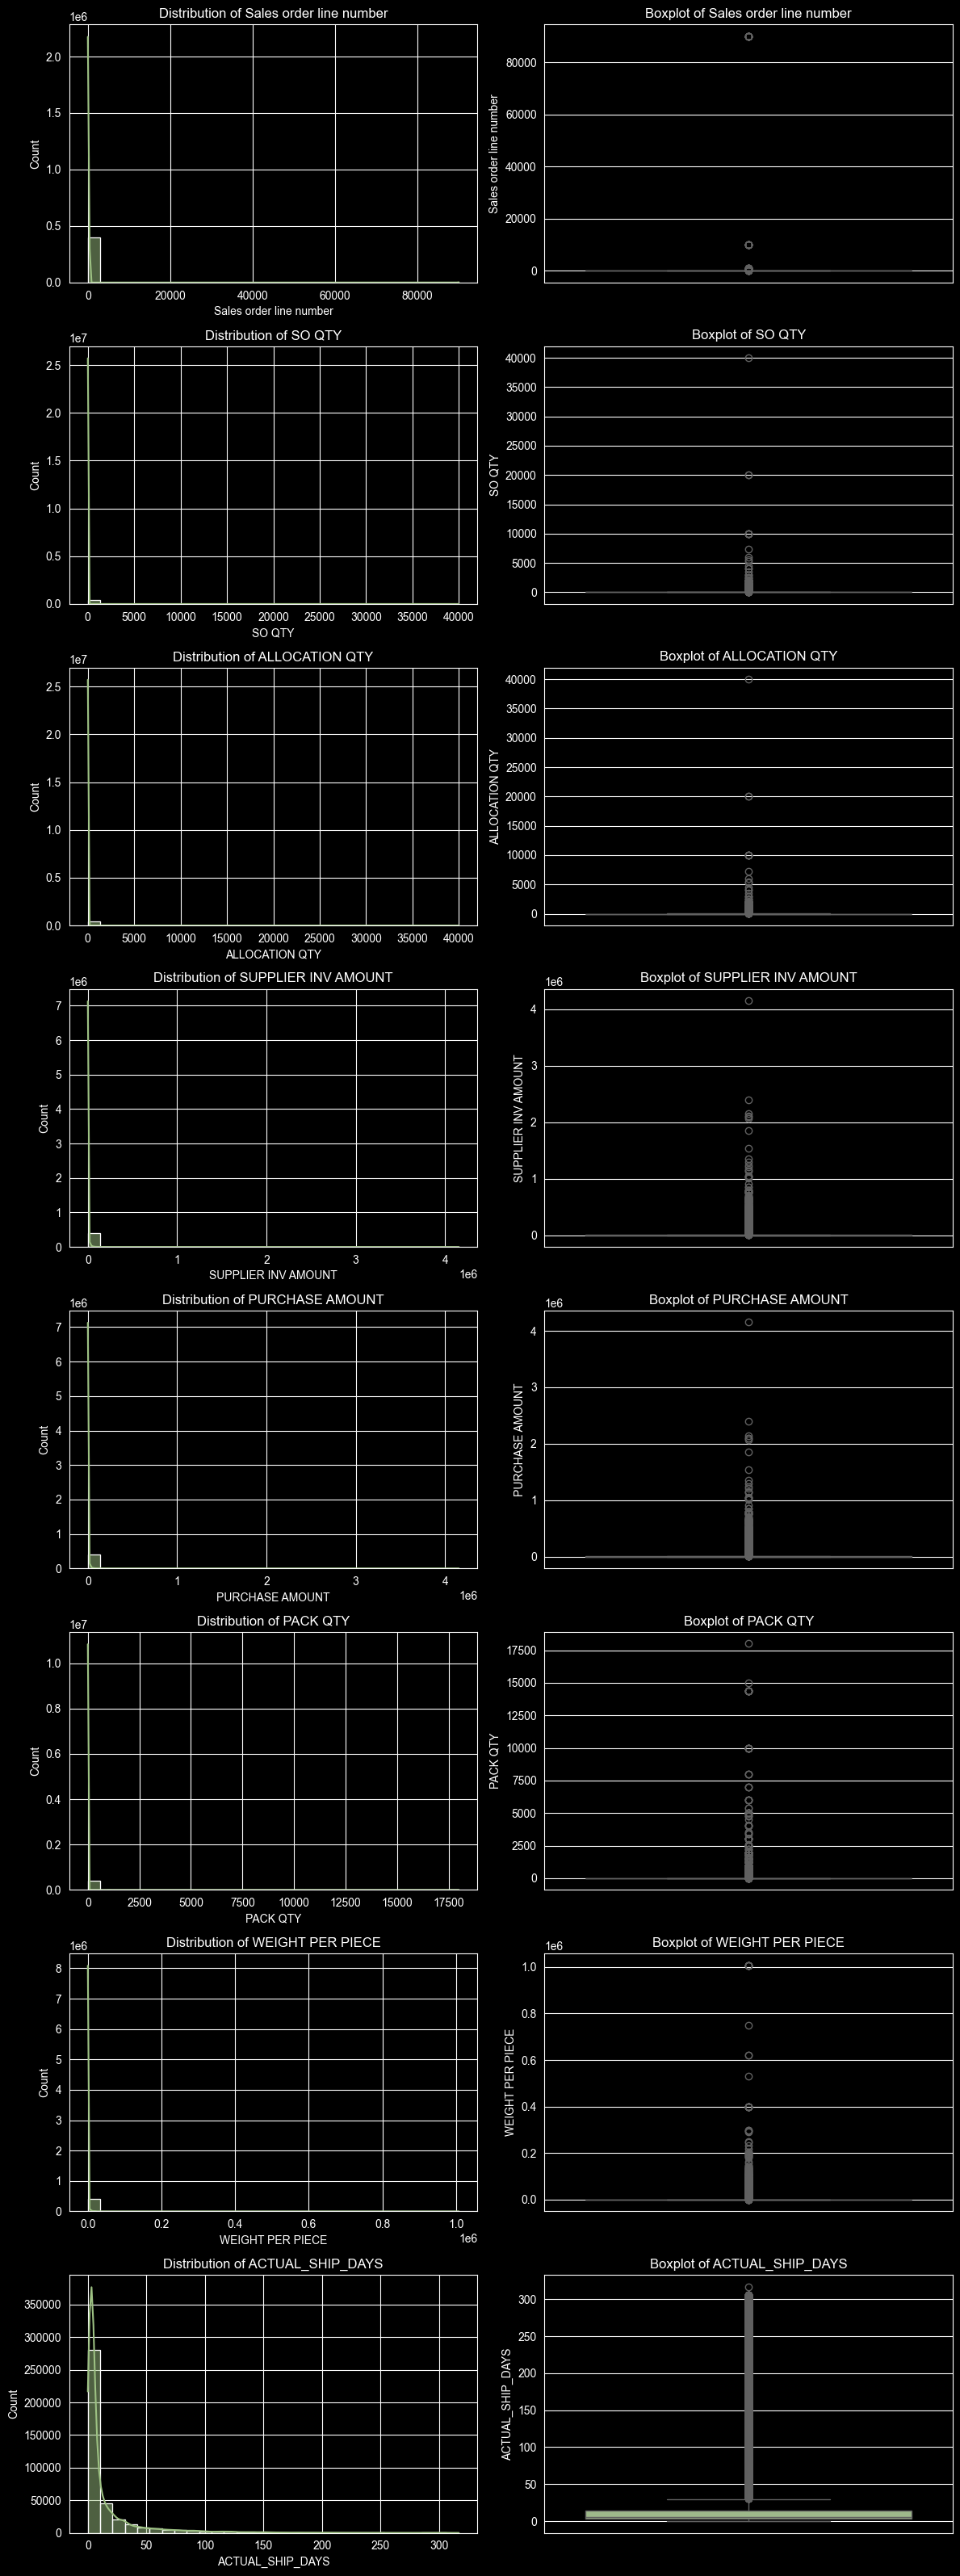

In [40]:
# Set sage green color palette
sage_color = "#9DC183"

# --- Combined plots: Distribution + Boxplot for numerical variables ---
print("EDA: Overview of the dataset for period 4-6")

fig, axes = plt.subplots(nrows=len(num_cols_4_6), ncols=2, figsize=(12, 4 * len(num_cols_4_6)))

for i, col in enumerate(num_cols_4_6):
    # Distribution plot
    sns.histplot(df_4_6[col], kde=True, bins=30, color=sage_color, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(y=df_4_6[col], color=sage_color, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig(f"combined_distribution_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

Most of numerical features havemany outliers and strong right skewness ==> Use winsorize function to reduce impact of extreme values without remove them.

In [41]:
def winsorize(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    original_outliers = ((data[column] < lower) | (data[column] > upper)).sum()

    # Clip outliers
    data[column] = data[column].clip(lower, upper)

    print(f"[{column}] Winsorized: {original_outliers} outliers clipped.")
    return data

In [42]:
# Apply winsorization to all numeric columns
for col in num_cols_4_6:
    df_4_6 = winsorize(df_4_6, col)

[Sales order line number] Winsorized: 52639 outliers clipped.
[SO QTY] Winsorized: 42508 outliers clipped.
[ALLOCATION QTY] Winsorized: 42508 outliers clipped.
[SUPPLIER INV AMOUNT] Winsorized: 44089 outliers clipped.
[PURCHASE AMOUNT] Winsorized: 44090 outliers clipped.
[PACK QTY] Winsorized: 8393 outliers clipped.
[WEIGHT PER PIECE] Winsorized: 49424 outliers clipped.
[ACTUAL_SHIP_DAYS] Winsorized: 53738 outliers clipped.


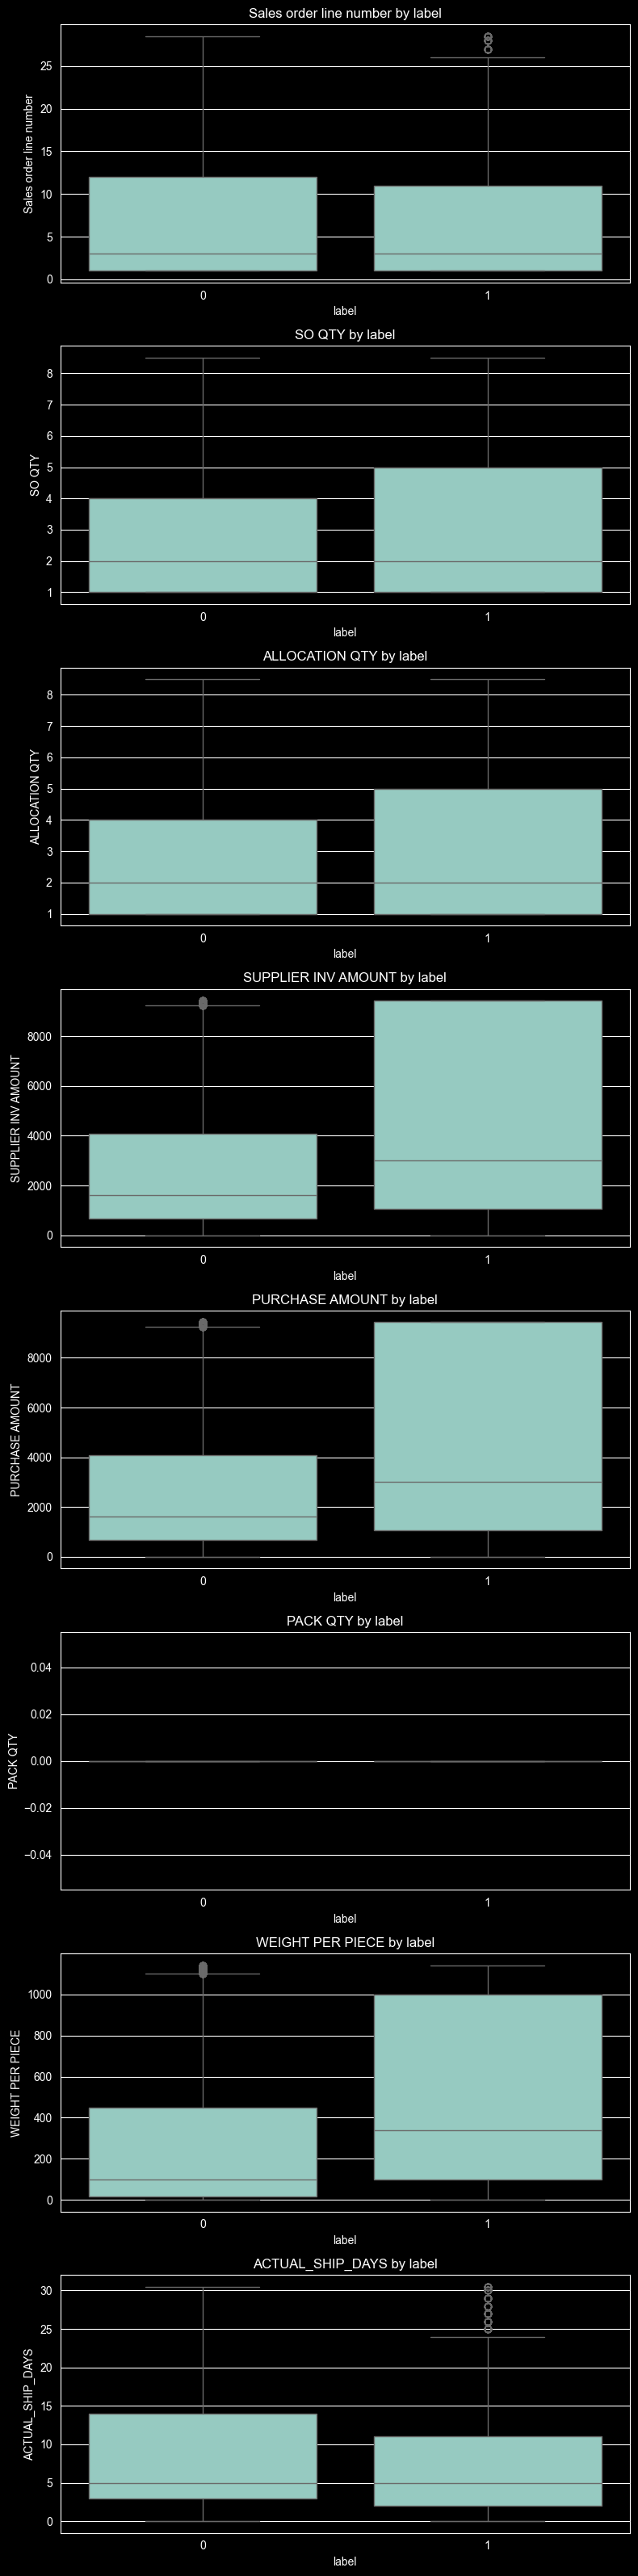

In [43]:
num_plots = len(num_cols_4_6)

fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(8, 4 * num_plots))

if num_plots == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols_4_6):
    sns.boxplot(x='label', y=col, data=df_4_6, ax=ax)
    ax.set_title(f"{col} by label")

plt.tight_layout()
plt.show()

- SUPPLIER INV AMOUNT & WEIGHT PER PIECE are potentially strong predictors since there is clear difference in medians and spread between labels.
- ALLOCATION QTY & ACTUAL_SHIP_DAYS moderately have predictive potential due to Slight difference in spread, but similar medians.

However, I decided to drop the variable ACTUAL\_SHIP\_DAYS because it is recorded after the delivery has taken place


In [44]:
df_4_6 = df_4_6.drop(columns=['ACTUAL_SHIP_DAYS'])
num_cols_4_6.remove('ACTUAL_SHIP_DAYS')

Categorical

In [45]:
# Display number of unique values per categorical column
for col in cat_cols_4_6:
    print(f"Variable: {col} has {df_4_6[col].nunique()} unique values")

Variable: GLOBAL_NO has 399049 unique values
Variable: CLASSIFY_CD has 4106 unique values
Variable: CUST_CD has 39070 unique values
Variable: BRAND_CD has 1755 unique values
Variable: INNER_CD has 110113 unique values
Variable: SUPPLIER_CD has 875 unique values
Variable: Consider count hodiday Saturday has 4 unique values
Variable: OTHER AREA SHIP DIV has 2 unique values
Variable: DELI_DIV has 10 unique values
Variable: SUPPLIER_DIV has 4 unique values
Variable: SPECIAL_DIV has 2 unique values
Variable: PACKING RANK has 7 unique values
Variable: PRODUCT_CD has 302476 unique values
Variable: LOGICAL PLANT has 3 unique values
Variable: label has 2 unique values
Variable: DIRECT SHIP FLG has 2 unique values
Variable: Ship Mode has 20 unique values
Variable: SHIP DECISION NO has 249901 unique values
Variable: SO_DAY_OF_MONTH has 31 unique values
Variable: SO_DAY_OF_WEEK has 6 unique values
Variable: SUPPLIER_CATEGORY_CD has 5 unique values


I dropped the columns "GLOBAL_NO", "PRODUCT_CD", and "SHIP DECISION NO" because:

- They have high uniqueness and behave like IDs, providing little generalizable information.

- The model cannot learn meaningful patterns from such identifiers.

In [46]:
drop_cols = ['GLOBAL_NO','PRODUCT_CD','SHIP DECISION NO']
df_4_6 = df_4_6.drop(columns=drop_cols)

# Update categorical features list:
cat_cols_4_6 =[cols for cols in cat_cols_4_6 if cols not in drop_cols]

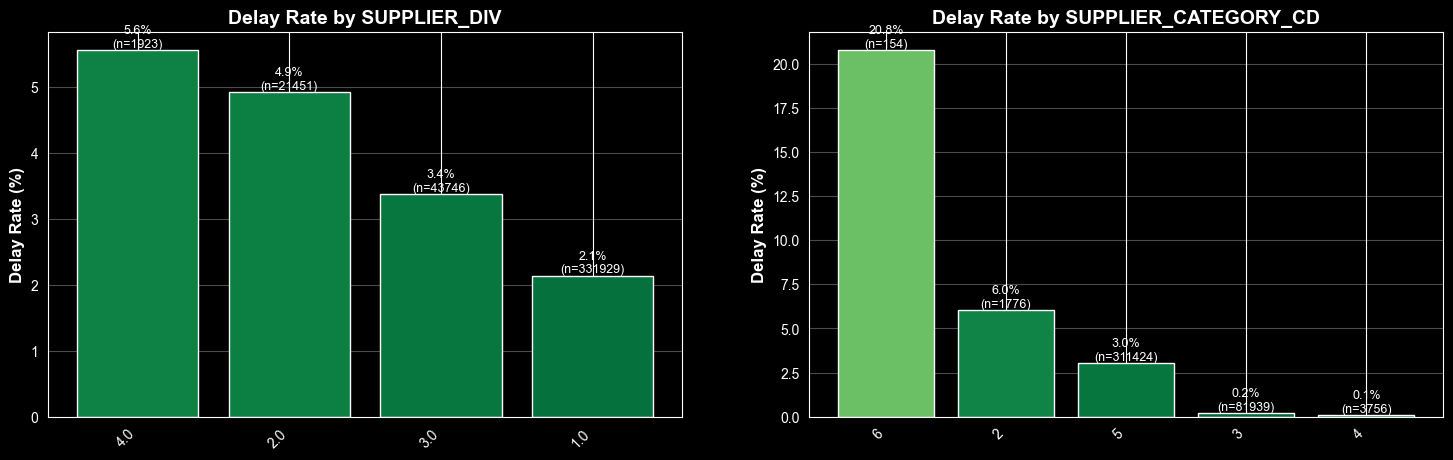

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Delay rate by SUPPLIER_DIV
ax1 = axes[0]
div_stats_4_6 = df_4_6.groupby('SUPPLIER_DIV').agg({
    'label': ['mean', 'count']
})
div_stats_4_6.columns = ['Delay_Rate', 'Count']
div_stats_4_6 = div_stats_4_6.sort_values('Delay_Rate', ascending=False)

bars = ax1.bar(range(len(div_stats_4_6)), div_stats_4_6['Delay_Rate'] * 100,
               color=plt.cm.RdYlGn_r(div_stats_4_6['Delay_Rate']))
ax1.set_xticks(range(len(div_stats_4_6)))
ax1.set_xticklabels(div_stats_4_6.index, rotation=45, ha='right')
ax1.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Delay Rate by SUPPLIER_DIV', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, div_stats_4_6['Count'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={count})',
            ha='center', va='bottom', fontsize=9)

# Delay rate by SUPPLIER_CATEGORY_CD
ax2 = axes[1]
if 'SUPPLIER_CATEGORY_CD' in df_4_6.columns:
    cat_stats_4_6 = df_4_6.groupby('SUPPLIER_CATEGORY_CD').agg({
        'label': ['mean', 'count']
    })
    cat_stats_4_6.columns = ['Delay_Rate', 'Count']
    cat_stats_4_6 = cat_stats_4_6.sort_values('Delay_Rate', ascending=False)

    bars = ax2.bar(range(len(cat_stats_4_6)), cat_stats_4_6['Delay_Rate'] * 100,
                  color=plt.cm.RdYlGn_r(cat_stats_4_6['Delay_Rate']))
    ax2.set_xticks(range(len(cat_stats_4_6)))
    ax2.set_xticklabels(cat_stats_4_6.index, rotation=45, ha='right')
    ax2.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Delay Rate by SUPPLIER_CATEGORY_CD', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    for i, (bar, count) in enumerate(zip(bars, cat_stats_4_6['Count'])):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%\n(n={count})',
                ha='center', va='bottom', fontsize=9)


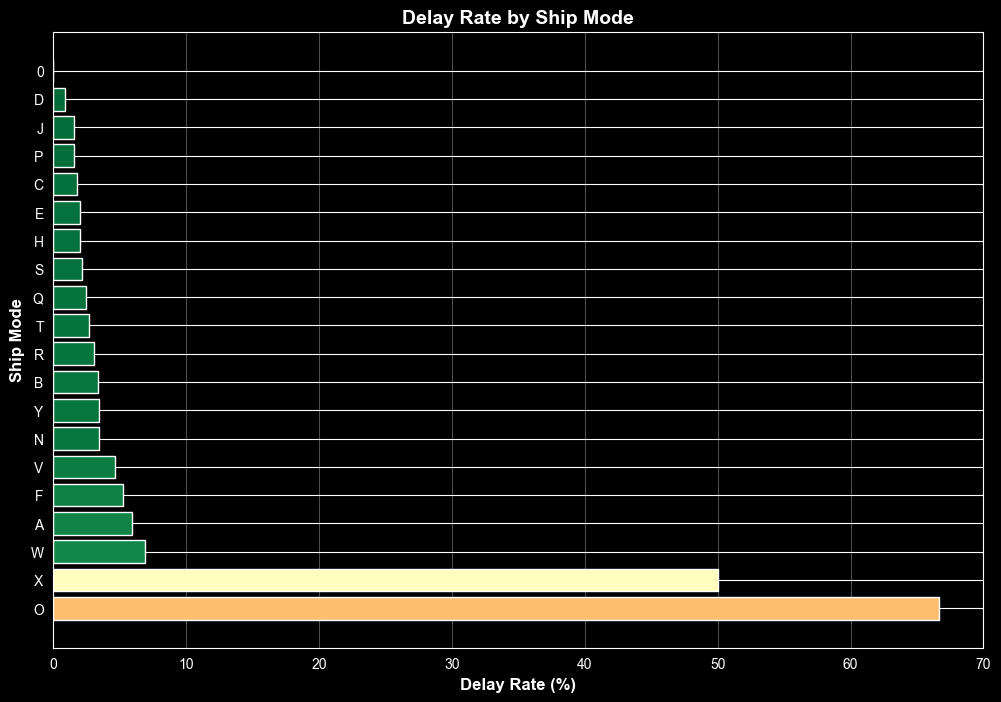

In [48]:
fig, axes = plt.subplots(1, figsize=(12, 8))

# Delay rate by Ship Mode
ax1 = axes
mode_stats_4_6 = df_4_6.groupby('Ship Mode').agg({
    'label': ['mean', 'count']
})
mode_stats_4_6.columns = ['Delay_Rate', 'Count']
mode_stats_4_6 = mode_stats_4_6.sort_values('Delay_Rate', ascending=False)

bars = ax1.barh(mode_stats_4_6.index.astype(str), mode_stats_4_6['Delay_Rate'] * 100,
                color=plt.cm.RdYlGn_r(mode_stats_4_6['Delay_Rate']))
ax1.set_xlabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ship Mode', fontsize=12, fontweight='bold')
ax1.set_title('Delay Rate by Ship Mode', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)


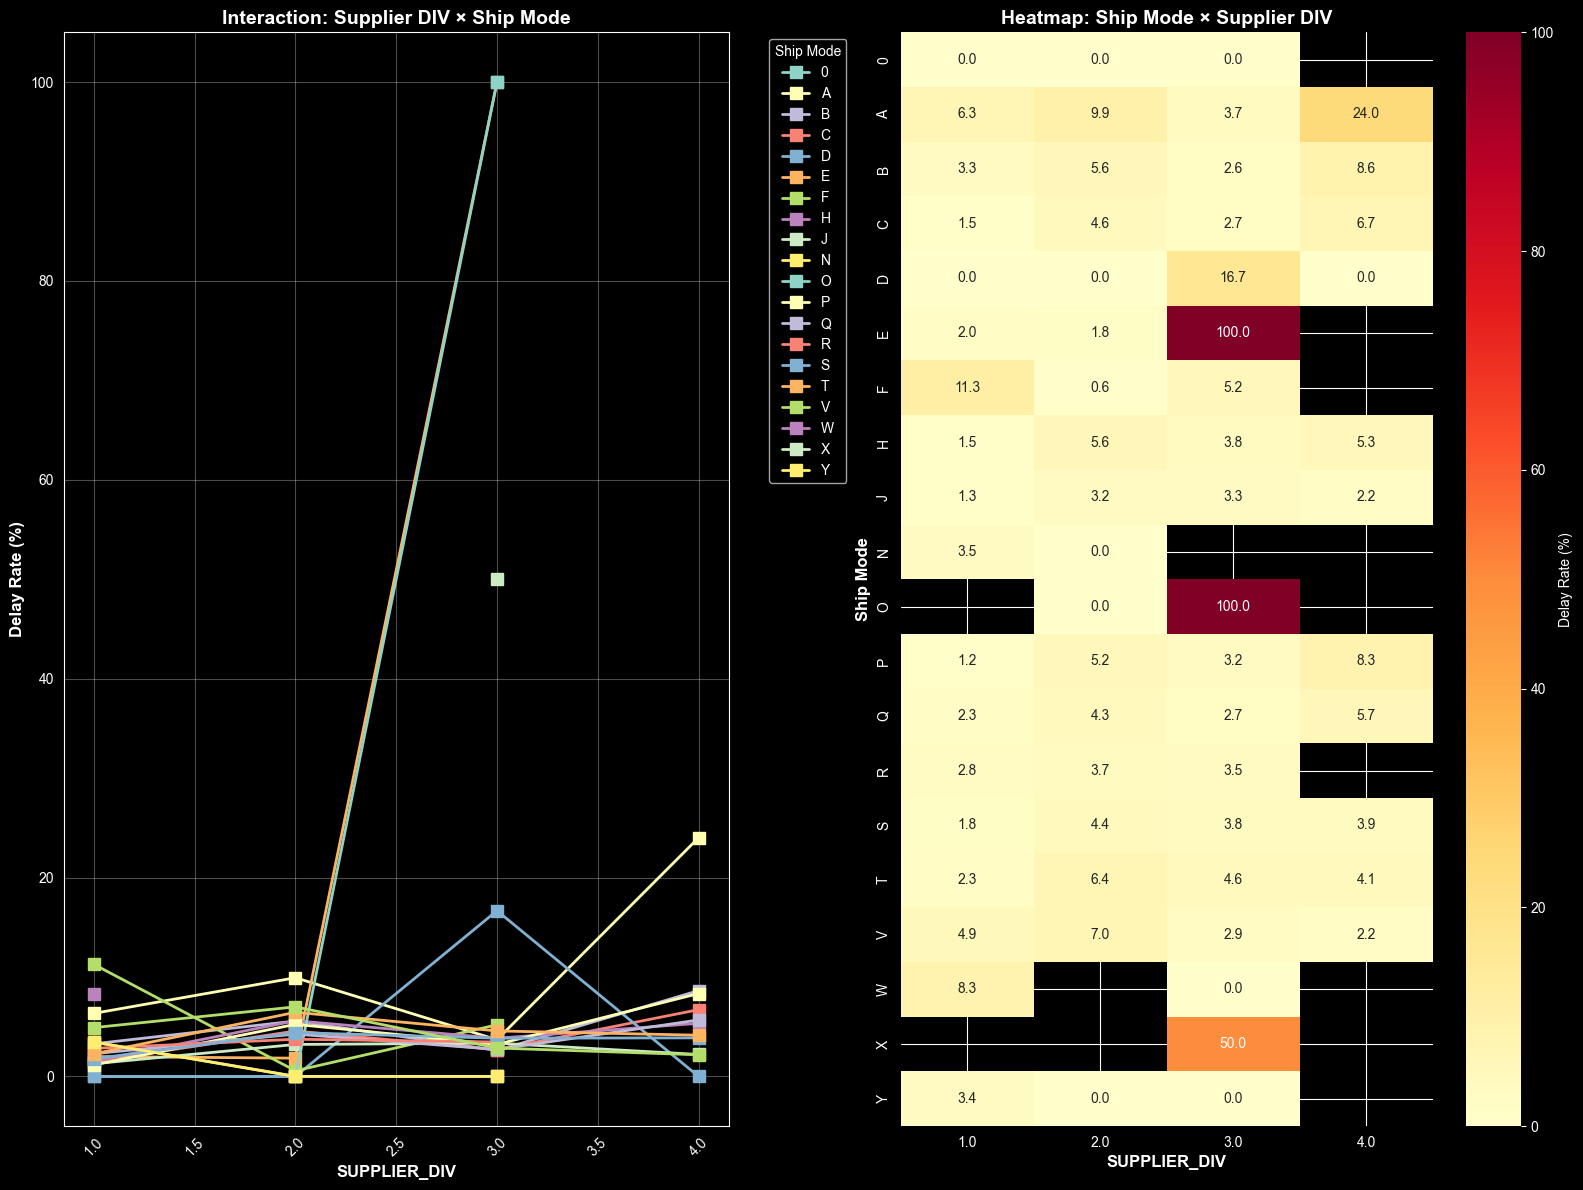

In [49]:
fig, axes = plt.subplots(1,2, figsize=(16, 12))


# Supplier DIV x Ship Mode
ax1 = axes[0]
interaction_1 = df_4_6.groupby(['SUPPLIER_DIV', 'Ship Mode'])['label'].mean().unstack()

for col in interaction_1.columns:
    ax1.plot(interaction_1.index, interaction_1[col] * 100,
            marker='s', linewidth=2, markersize=8, label=col)

ax1.set_xlabel('SUPPLIER_DIV', fontsize=12, fontweight='bold')
ax1.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Interaction: Supplier DIV × Ship Mode', fontsize=14, fontweight='bold')
ax1.legend(title='Ship Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
# Heatmap - Ship Mode x Supplier DIV
ax2 = axes[1]
heatmap_data = df_4_6.groupby(['Ship Mode', 'SUPPLIER_DIV'])['label'].mean().unstack() * 100

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax2, cbar_kws={'label': 'Delay Rate (%)'})
ax2.set_xlabel('SUPPLIER_DIV', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ship Mode', fontsize=12, fontweight='bold')
ax2.set_title('Heatmap: Ship Mode × Supplier DIV', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('interaction_plots.png', dpi=300, bbox_inches='tight')
plt.show()

*1. Supplier Division (SUPPLIER_DIV)*

- Division 4 has the highest delay rate, followed by 2, 3, and 1 (4 > 2 > 3 > 1).

- The delay rate ranges approximately from 5.6% down to 2%.

- Several ship modes are unavailable depending on the division (e.g., Div 1 has no O & X; Div 4 lacks many modes such as O, E, F, N, R, W, X, Y).

*2. Supplier Category (SUPPLIER_CATEGORY_CD)*

- Category 6 has the highest delay rate (20.8%), which is more than double the combined rate of the remaining categories.

- The ranking of delay rate is: 6 > 2 > 5 > 3 > 4.

*3. Ship Mode*

- Ship modes X and O have extremely high delay rates (50% and 66.7%).

- Ship mode X appears only in Division 3.

- The combination of Ship Mode E & O with Division 3 shows a 100% delay rate.

- Ship Mode X with Division 3 shows a 50% delay rate.

***Overall:***
Delivery delays are strongly associated with specific supplier divisions (especially Division 4), Supplier Category 6, and certain ship modes (notably X and O). Some division–ship mode combinations show extremely high delay rates (up to 100%).

## Statistical Testing ##

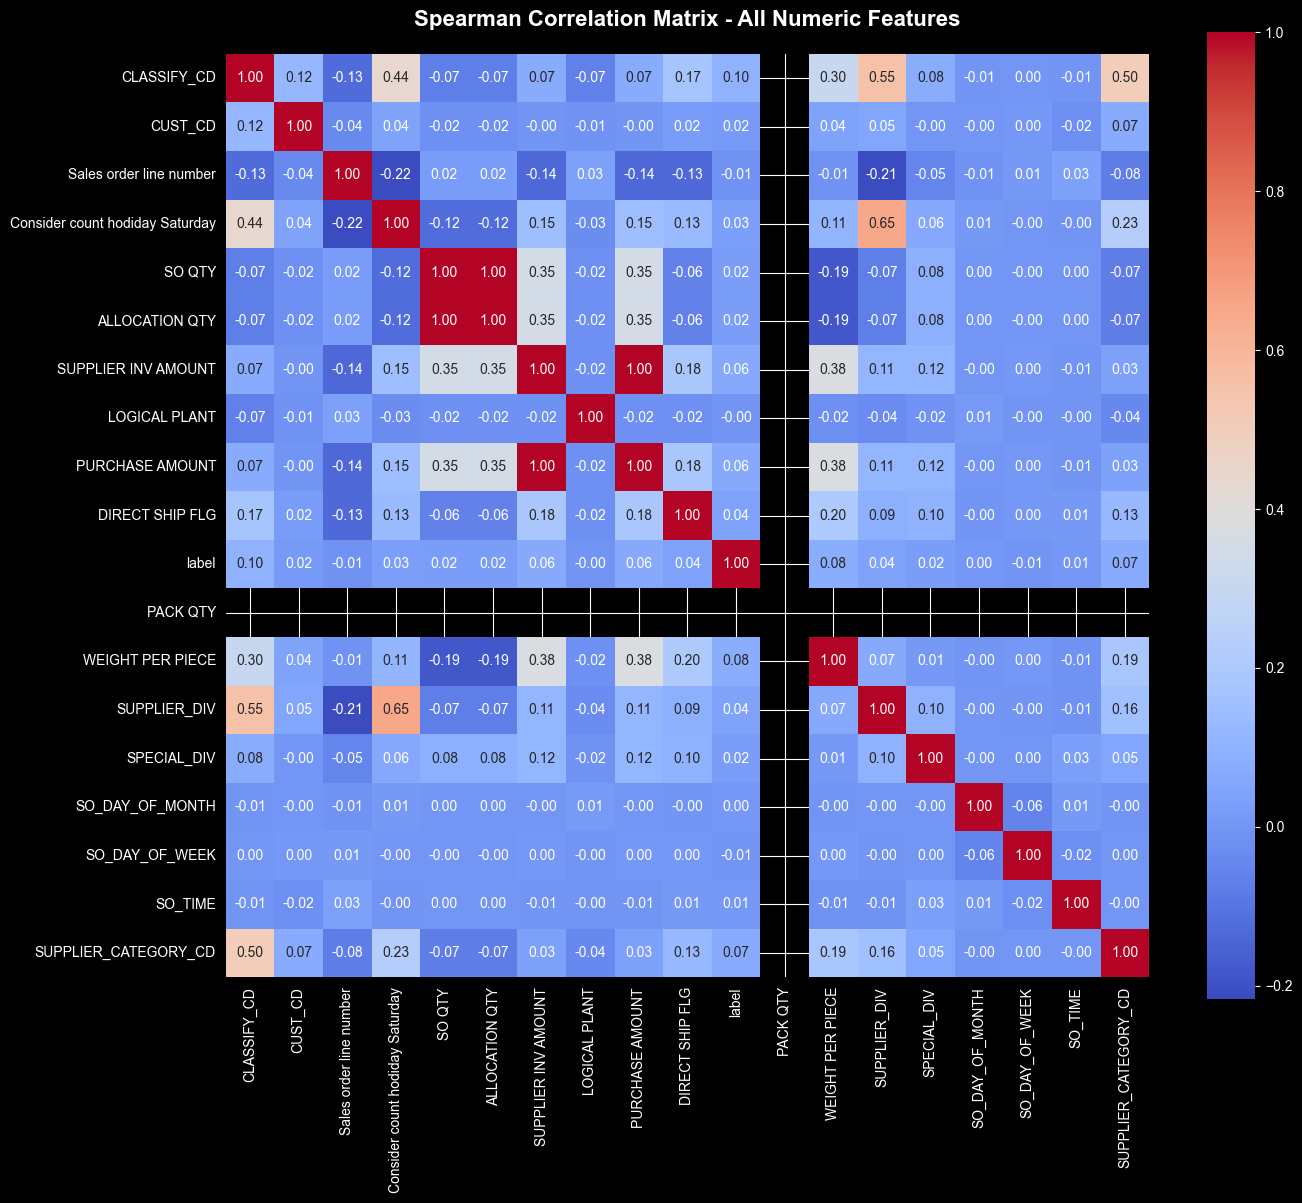


Removing constant columns:
['PACK QTY']


C:\Users\ADMIN\Documents\K19\Nam 2\TXLDATA\delay_pred\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Initial VIF Results:
                            Feature           VIF
4                            SO QTY           inf
5                    ALLOCATION QTY           inf
6               SUPPLIER INV AMOUNT  2.107872e+04
8                   PURCHASE AMOUNT  2.107825e+04
7                     LOGICAL PLANT  6.886503e+01
16             SUPPLIER_CATEGORY_CD  3.532506e+01
15                          SO_TIME  2.013476e+01
11                     SUPPLIER_DIV  1.273717e+01
14                   SO_DAY_OF_WEEK  5.300261e+00
0                       CLASSIFY_CD  5.029827e+00
13                  SO_DAY_OF_MONTH  4.657961e+00
3   Consider count hodiday Saturday  2.578741e+00
10                 WEIGHT PER PIECE  2.228212e+00
1                           CUST_CD  1.962085e+00
2           Sales order line number  1.864004e+00
9                   DIRECT SHIP FLG  1.263130e+00
12                      SPECIAL_DIV  1.061305e+00


C:\Users\ADMIN\Documents\K19\Nam 2\TXLDATA\delay_pred\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Removing 'SO QTY' with VIF = inf

Removing 'SUPPLIER INV AMOUNT' with VIF = 21078.72

Removing 'LOGICAL PLANT' with VIF = 68.83

Removing 'SUPPLIER_CATEGORY_CD' with VIF = 19.21

Removing 'SUPPLIER_DIV' with VIF = 11.24

FINAL VIF RESULTS
                            Feature       VIF
11                          SO_TIME  8.764049
10                   SO_DAY_OF_WEEK  4.500530
9                   SO_DAY_OF_MONTH  4.105588
4                    ALLOCATION QTY  3.164315
5                   PURCHASE AMOUNT  3.008643
0                       CLASSIFY_CD  2.999210
3   Consider count hodiday Saturday  2.256675
7                  WEIGHT PER PIECE  2.118266
1                           CUST_CD  1.902477
2           Sales order line number  1.811844
6                   DIRECT SHIP FLG  1.257794
8                       SPECIAL_DIV  1.056617


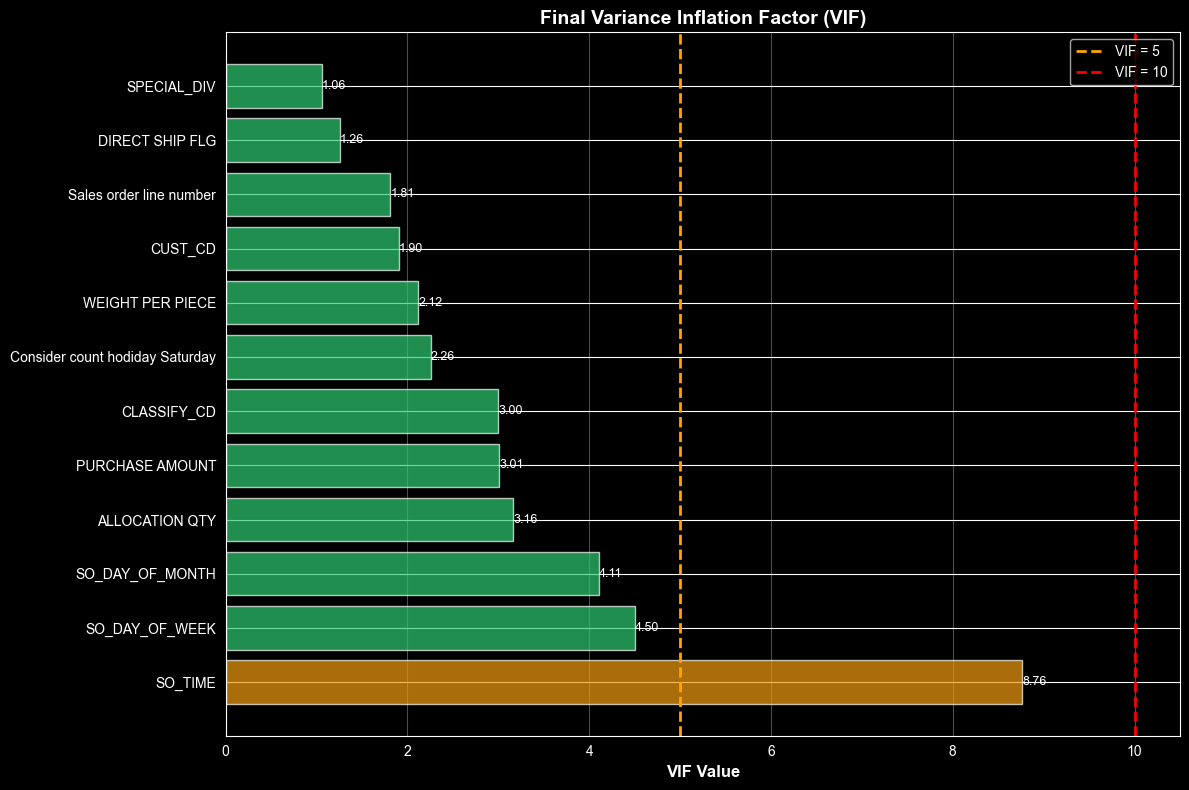

REMOVED FEATURES:
['SO QTY', 'SUPPLIER INV AMOUNT', 'LOGICAL PLANT', 'SUPPLIER_CATEGORY_CD', 'SUPPLIER_DIV']

Remaining features:
['Order date', 'CLASSIFY_CD', 'CUST_CD', 'BRAND_CD', 'INNER_CD', 'SUPPLIER_CD', 'Sales order line number', 'Consider count hodiday Saturday', 'OTHER AREA SHIP DIV', 'ALLOCATION QTY', 'PACKING RANK', 'PURCHASE AMOUNT', 'VSD', 'DIRECT SHIP FLG', 'DELI_DIV', 'label', 'Ship Mode', 'PACK QTY', 'WEIGHT PER PIECE', 'SPECIAL_DIV', 'SO_DAY_OF_MONTH', 'SO_DAY_OF_WEEK', 'SO_TIME']


In [50]:
from scipy.stats import spearmanr, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation
numeric_cols = df_4_6.select_dtypes(include=[np.number]).columns.tolist()

spearman_corr = df_4_6[numeric_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
ax.set_title('Spearman Correlation Matrix - All Numeric Features',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# VIF
numeric_cols = df_4_6.select_dtypes(include=[np.number]).columns.tolist()

# Remove target column
if 'label' in numeric_cols:
    numeric_cols.remove('label')

# Prepare data
vif_data = df_4_6[numeric_cols].copy()

# Remove inf values
vif_data = vif_data.replace([np.inf, -np.inf], np.nan)

# Drop missing rows
vif_data = vif_data.dropna()

# Remove constant columns
constant_cols = [
    col for col in vif_data.columns
    if vif_data[col].nunique() <= 1
]

if constant_cols:
    print("\nRemoving constant columns:")
    print(constant_cols)

    vif_data = vif_data.drop(columns=constant_cols)

# Function to calculate VIF
def calculate_vif(dataframe):
    vif_results = []

    for i, col in enumerate(dataframe.columns):
        try:
            vif_value = variance_inflation_factor(dataframe.values, i)
            vif_results.append({
                'Feature': col,
                'VIF': vif_value
            })
        except Exception as e:
            print(f"Error calculating VIF for {col}: {e}")
            vif_results.append({
                'Feature': col,
                'VIF': np.nan
            })

    vif_df = pd.DataFrame(vif_results)
    return vif_df.sort_values('VIF', ascending=False)

# Initial VIF
vif_df = calculate_vif(vif_data)

print("\nInitial VIF Results:")
print(vif_df)

# Remove features with extremely high VIF
VIF_THRESHOLD = 10
removed_features = []

while True:
    vif_df = calculate_vif(vif_data)
    max_vif = vif_df['VIF'].max()
    if max_vif <= VIF_THRESHOLD or np.isnan(max_vif):
        break

    feature_to_remove = vif_df.iloc[0]['Feature']
    print(f"\nRemoving '{feature_to_remove}' with VIF = {max_vif:.2f}")
    removed_features.append(feature_to_remove)
    vif_data = vif_data.drop(columns=[feature_to_remove])

# Final VIF Results
final_vif_df = calculate_vif(vif_data)

print("FINAL VIF RESULTS:")

print(final_vif_df)

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

colors = [
    '#e74c3c' if x > 10 else
    '#f39c12' if x > 5 else
    '#2ecc71'
    for x in final_vif_df['VIF']
]

bars = ax.barh(
    range(len(final_vif_df)),
    final_vif_df['VIF'],
    color=colors,
    alpha=0.7
)

ax.set_yticks(range(len(final_vif_df)))
ax.set_yticklabels(final_vif_df['Feature'])

ax.set_xlabel('VIF Value', fontsize=12, fontweight='bold')
ax.set_title(
    'Final Variance Inflation Factor (VIF)',
    fontsize=14,
    fontweight='bold'
)
ax.axvline(
    x=5,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='VIF = 5'
)
ax.axvline(
    x=10,
    color='red',
    linestyle='--',
    linewidth=2,
    label='VIF = 10'
)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add VIF values
for bar, val in zip(bars, final_vif_df['VIF']):

    if np.isfinite(val):

        ax.text(
            val,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            ha='left',
            va='center',
            fontsize=9
        )
plt.tight_layout()
plt.savefig(
    'final_vif_analysis.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Summary
print("REMOVED FEATURES:")
print(removed_features)

# Update df
df_4_6 = df_4_6.drop(columns=removed_features)

print("\nRemaining features:")
print(df_4_6.columns.tolist())

## Dataset Jul - Sep ##

Applied the same with dataset Apr - June

EDA: Overview of the dataset for period 7-9


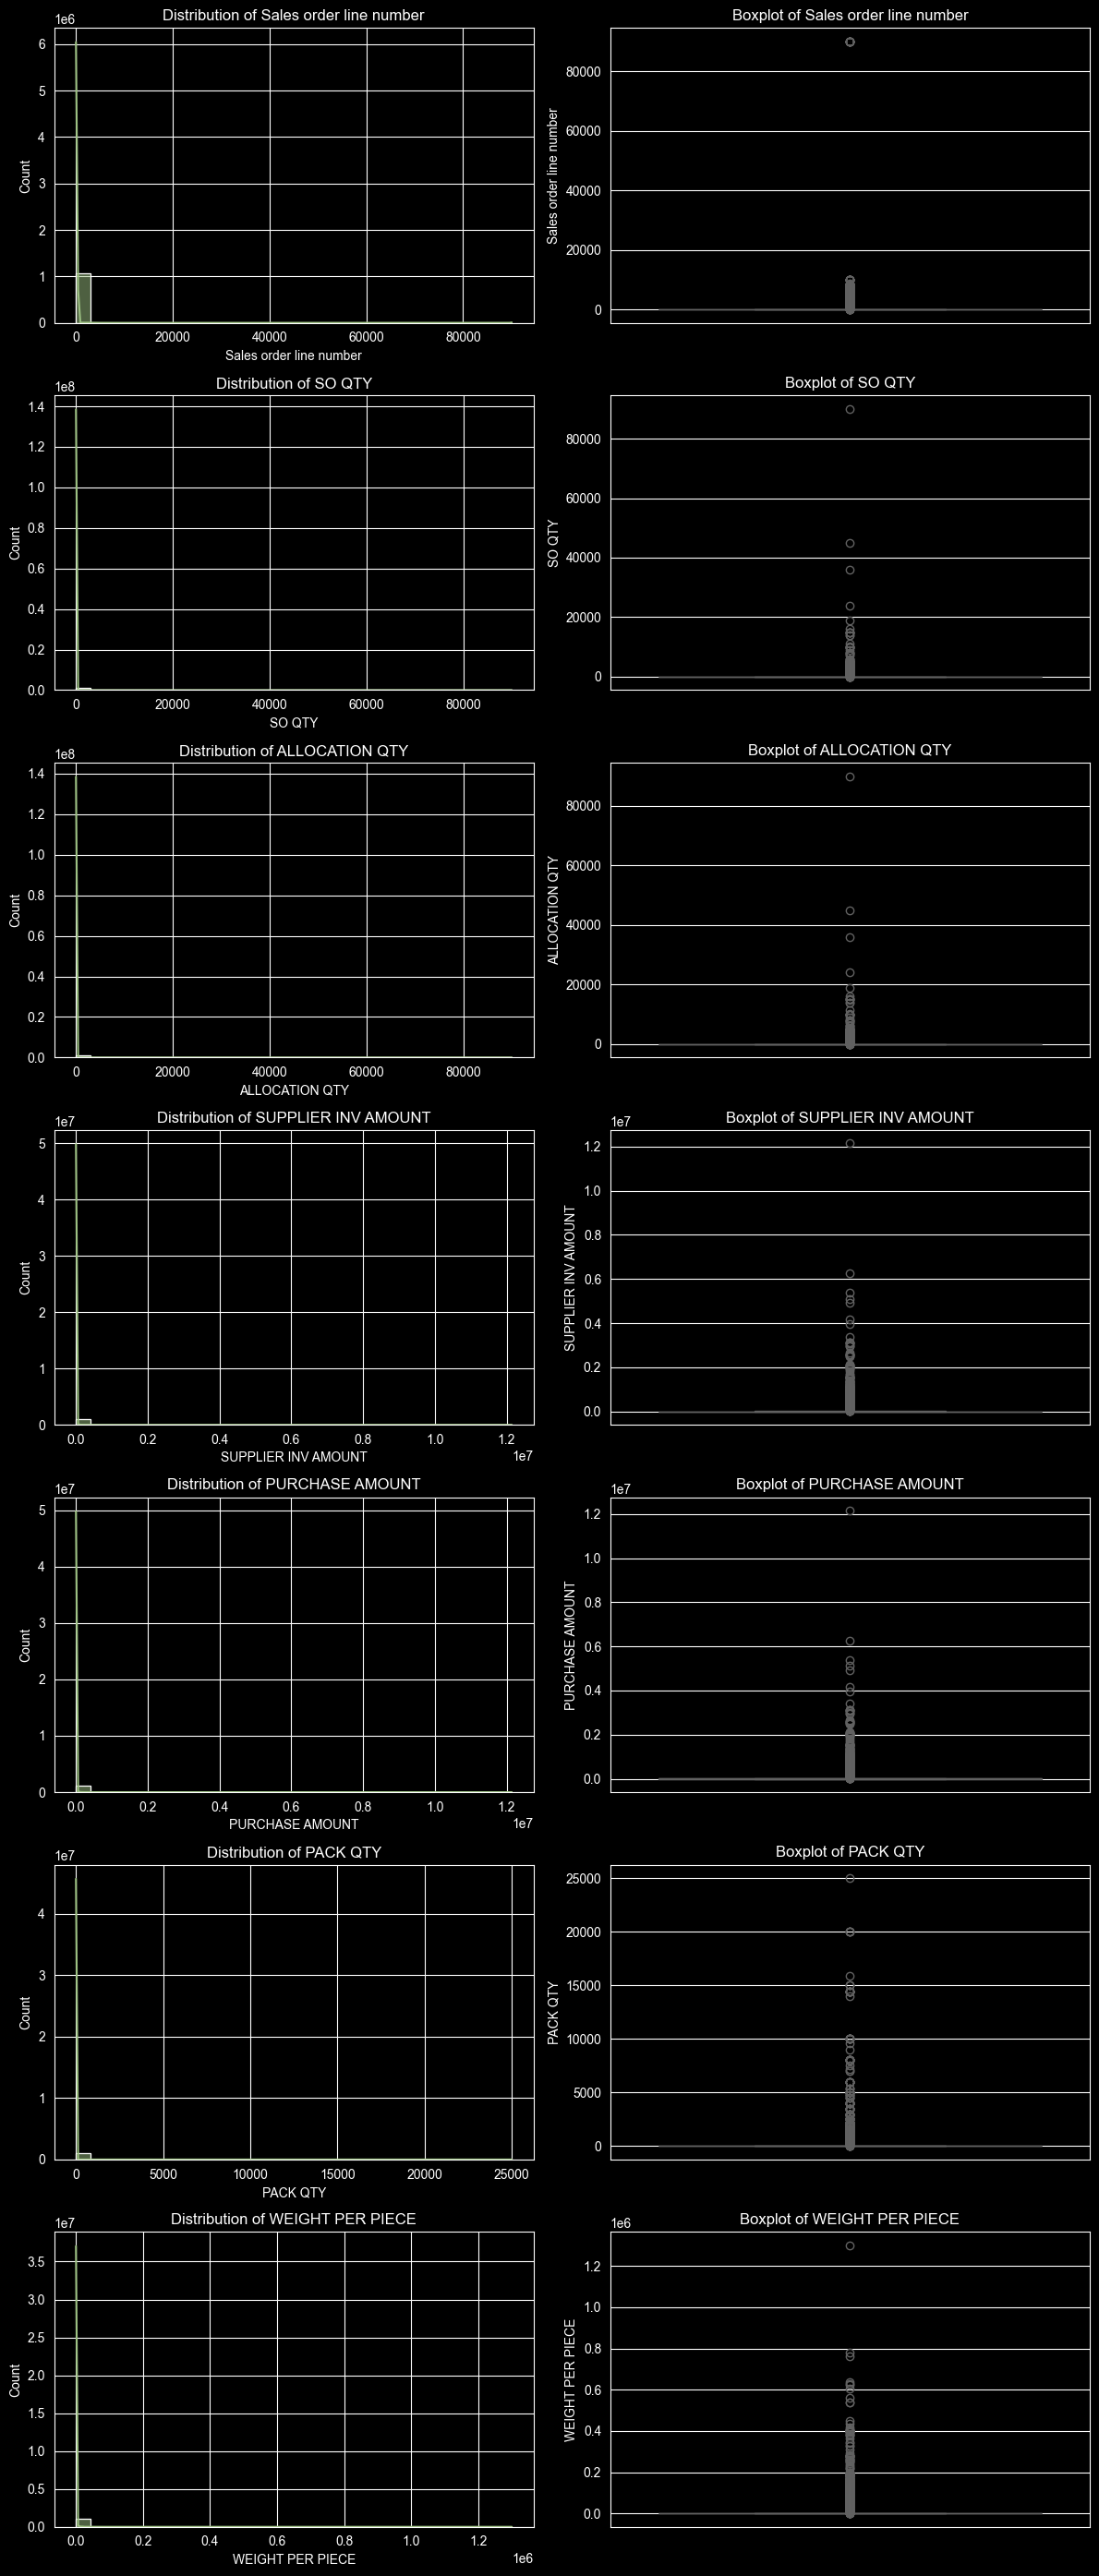

In [51]:
# Set sage green color palette
sage_color = "#9DC183"

# --- Combined plots: Distribution + Boxplot for numerical variables ---
print("EDA: Overview of the dataset for period 7-9")

fig, axes = plt.subplots(nrows=len(num_cols_7_9), ncols=2, figsize=(12, 4 * len(num_cols_7_9)))

for i, col in enumerate(num_cols_7_9):
    # Distribution plot
    sns.histplot(df_7_9[col], kde=True, bins=30, color=sage_color, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(y=df_7_9[col], color=sage_color, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig(f"combined_distribution_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

In [52]:
for col in num_cols_7_9:
    df_7_9 = winsorize(df_7_9, col)

[Sales order line number] Winsorized: 139854 outliers clipped.
[SO QTY] Winsorized: 127055 outliers clipped.
[ALLOCATION QTY] Winsorized: 127055 outliers clipped.
[SUPPLIER INV AMOUNT] Winsorized: 120076 outliers clipped.
[PURCHASE AMOUNT] Winsorized: 120134 outliers clipped.
[PACK QTY] Winsorized: 24225 outliers clipped.
[WEIGHT PER PIECE] Winsorized: 133326 outliers clipped.


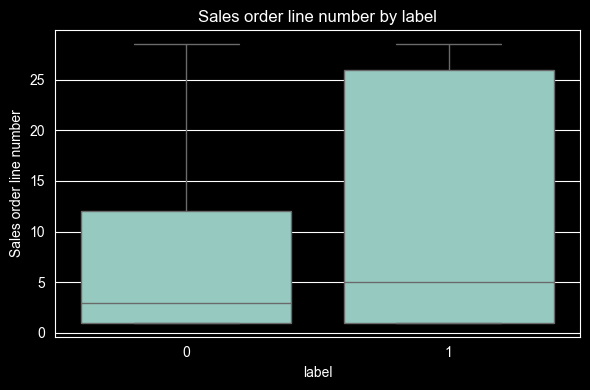

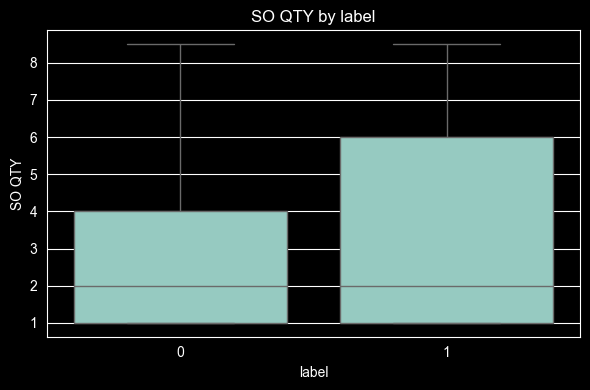

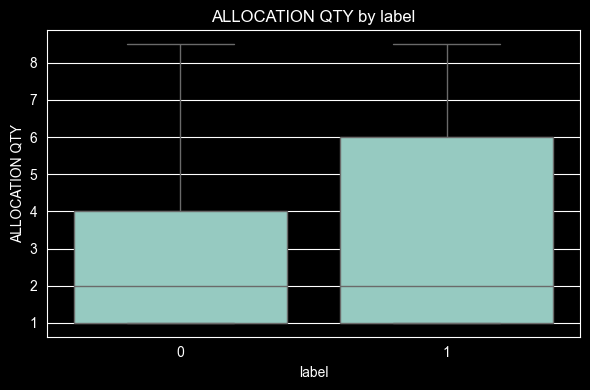

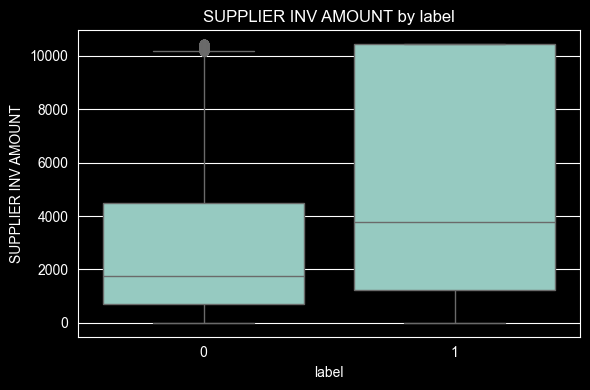

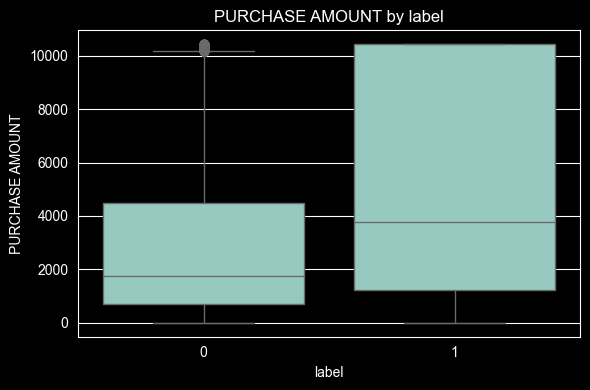

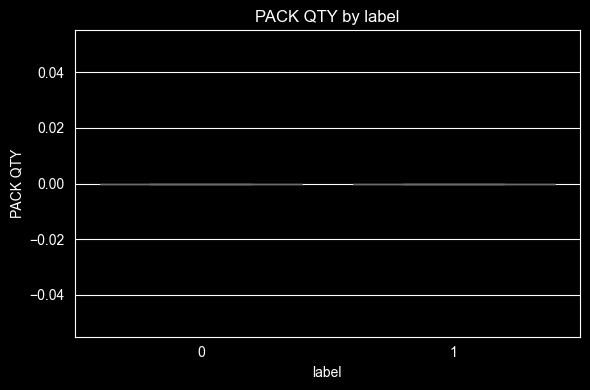

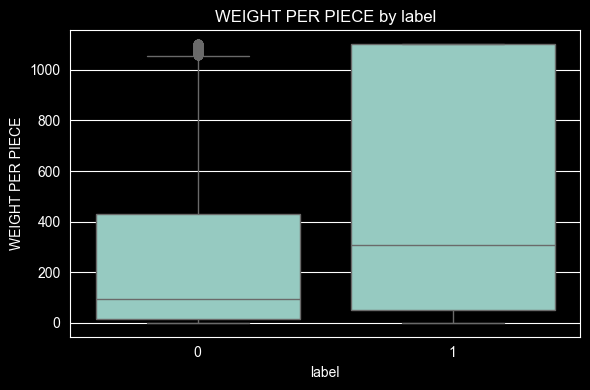

In [53]:
# Boxplots of numerical features by label
for col in num_cols_7_9:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='label', y=col, data=df_7_9)
    plt.title(f"{col} by label")
    plt.tight_layout()
    plt.show()

- SUPPLIER INV AMOUNT & WEIGHT PER PIECE are potentially strong predictors.
- ALLOCATION QTY & Sales order line number moderately are moderate predictors.
- PACK QTY are weak predictors.

In [55]:
# Display number of unique values per categorical column
for col in cat_cols_7_9:
    print(f"Variable: {col} has {df_7_9[col].nunique()} unique values")

Variable: GLOBAL_NO has 1074897 unique values
Variable: CLASSIFY_CD has 5035 unique values
Variable: CUST_CD has 51456 unique values
Variable: BRAND_CD has 2014 unique values
Variable: INNER_CD has 214841 unique values
Variable: SUPPLIER_CD has 932 unique values
Variable: Consider count hodiday Saturday has 4 unique values
Variable: OTHER AREA SHIP DIV has 2 unique values
Variable: DELI_DIV has 10 unique values
Variable: SUPPLIER_DIV has 4 unique values
Variable: SPECIAL_DIV has 2 unique values
Variable: PACKING RANK has 7 unique values
Variable: PRODUCT_CD has 717622 unique values
Variable: LOGICAL PLANT has 3 unique values
Variable: DIRECT SHIP FLG has 2 unique values
Variable: label has 2 unique values
Variable: Ship Mode has 20 unique values
Variable: SHIP DECISION NO has 460324 unique values
Variable: SO_DAY_OF_MONTH has 31 unique values
Variable: SO_DAY_OF_WEEK has 6 unique values


In [56]:
# Drop unnecessary columns
drop_cols = ['GLOBAL_NO', 'PRODUCT_CD', "SHIP DECISION NO"]
df_7_9 = df_7_9.drop(columns=drop_cols)

# Update the list of categorical columns
cat_cols_7_9 = [col for col in cat_cols_7_9 if col not in drop_cols]

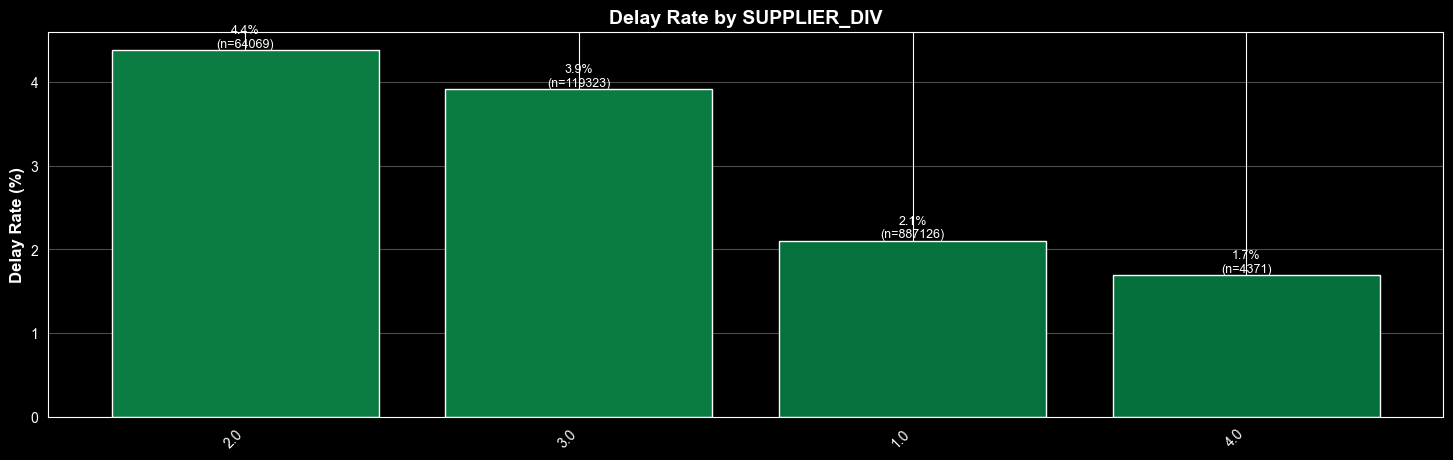

In [58]:
fig, axes = plt.subplots(1, figsize=(18, 5))

# Delay rate by SUPPLIER_DIV
ax1 = axes
div_stats_7_9 = df_7_9.groupby('SUPPLIER_DIV').agg({
    'label': ['mean', 'count']
})
div_stats_7_9.columns = ['Delay_Rate', 'Count']
div_stats_7_9 = div_stats_7_9.sort_values('Delay_Rate', ascending=False)

bars = ax1.bar(range(len(div_stats_7_9)), div_stats_7_9['Delay_Rate'] * 100,
               color=plt.cm.RdYlGn_r(div_stats_7_9['Delay_Rate']))
ax1.set_xticks(range(len(div_stats_7_9)))
ax1.set_xticklabels(div_stats_7_9.index, rotation=45, ha='right')
ax1.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Delay Rate by SUPPLIER_DIV', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, div_stats_7_9['Count'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={count})',
            ha='center', va='bottom', fontsize=9)

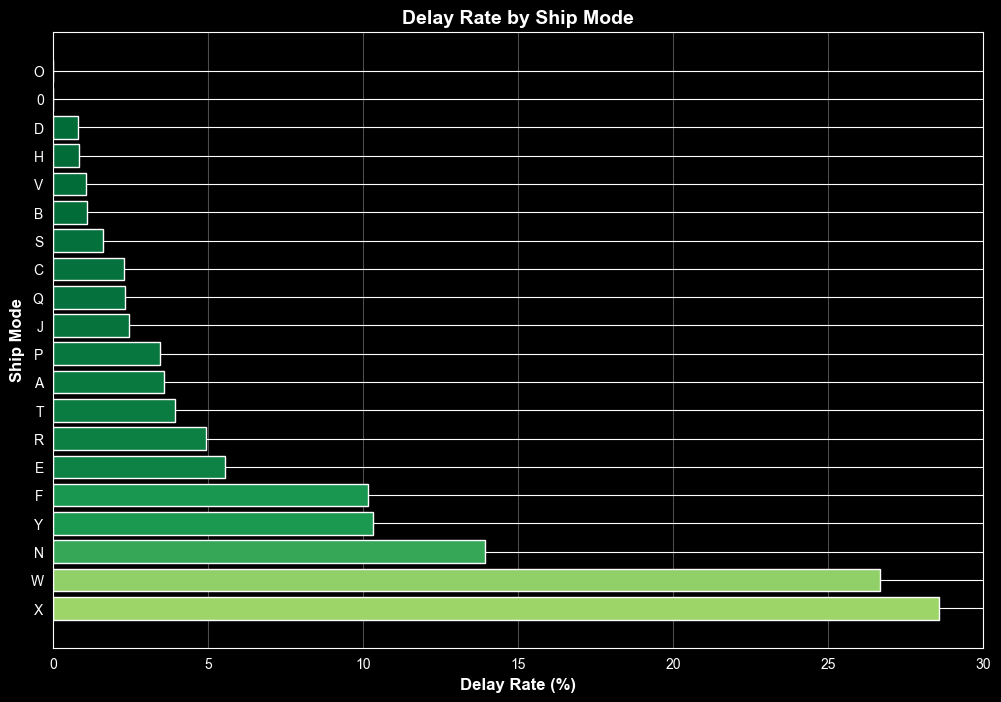

In [59]:
fig, axes = plt.subplots(1, figsize=(12, 8))

# Delay rate by Ship Mode
ax1 = axes
mode_stats_7_9 = df_7_9.groupby('Ship Mode').agg({
    'label': ['mean', 'count']
})
mode_stats_7_9.columns = ['Delay_Rate', 'Count']
mode_stats_7_9 = mode_stats_7_9.sort_values('Delay_Rate', ascending=False)

bars = ax1.barh(mode_stats_7_9.index.astype(str), mode_stats_7_9['Delay_Rate'] * 100,
                color=plt.cm.RdYlGn_r(mode_stats_7_9['Delay_Rate']))
ax1.set_xlabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ship Mode', fontsize=12, fontweight='bold')
ax1.set_title('Delay Rate by Ship Mode', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)


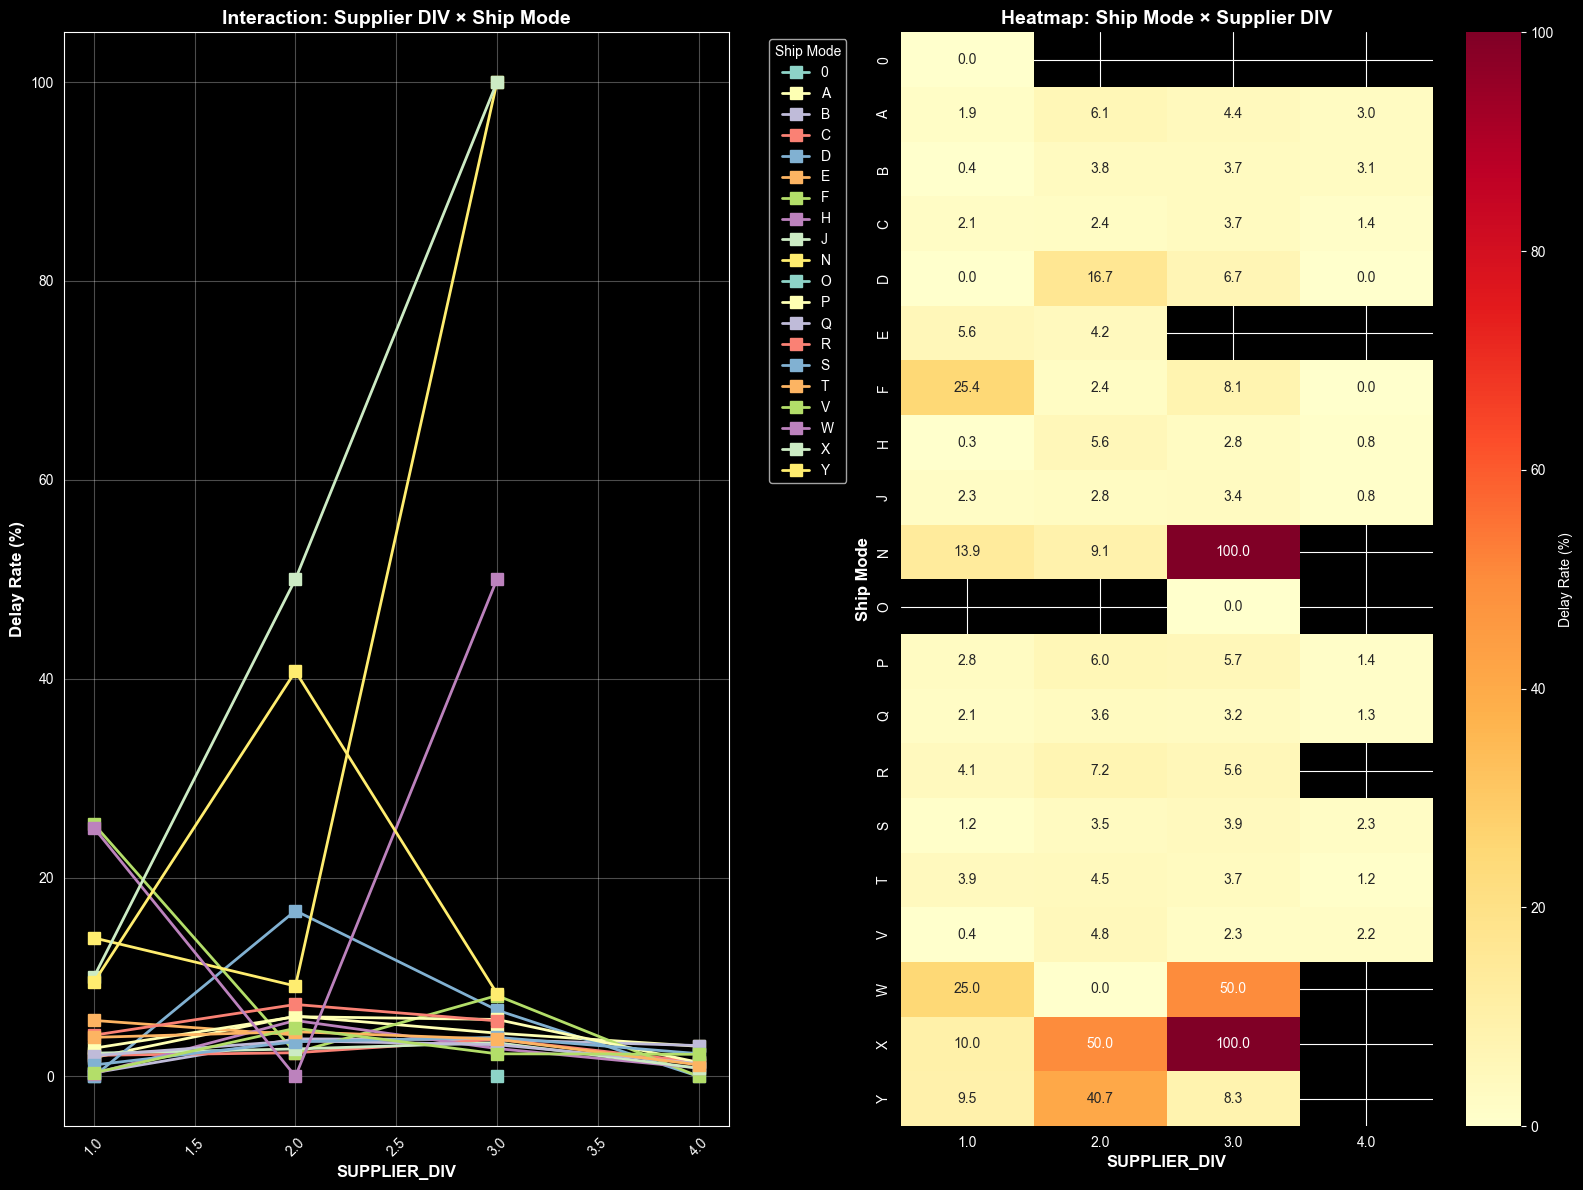

In [60]:
fig, axes = plt.subplots(1,2, figsize=(16, 12))


# Supplier DIV x Ship Mode
ax1 = axes[0]
interaction_1 = df_7_9.groupby(['SUPPLIER_DIV', 'Ship Mode'])['label'].mean().unstack()

for col in interaction_1.columns:
    ax1.plot(interaction_1.index, interaction_1[col] * 100,
            marker='s', linewidth=2, markersize=8, label=col)

ax1.set_xlabel('SUPPLIER_DIV', fontsize=12, fontweight='bold')
ax1.set_ylabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Interaction: Supplier DIV × Ship Mode', fontsize=14, fontweight='bold')
ax1.legend(title='Ship Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
# Heatmap - Ship Mode x Supplier DIV
ax2 = axes[1]
heatmap_data = df_7_9.groupby(['Ship Mode', 'SUPPLIER_DIV'])['label'].mean().unstack() * 100

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax2, cbar_kws={'label': 'Delay Rate (%)'})
ax2.set_xlabel('SUPPLIER_DIV', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ship Mode', fontsize=12, fontweight='bold')
ax2.set_title('Heatmap: Ship Mode × Supplier DIV', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('interaction_plots.png', dpi=300, bbox_inches='tight')
plt.show()

*1. Overall Trend*

- The overall delay rate significantly decreased compared to April–June.

*2. Supplier Division (SUPPLIER_DIV)*

- Delay rates decrease in the order: 2 > 3 > 1 > 4 (from 4.4% to 1.7%).

- Division 4 now has the lowest delay rate (improvement compared to Dataset A).

- Some ship modes remain unavailable in certain divisions (e.g., Div 4 lacks E, N, O, R, W, X, Y; Div 3 lacks E; Ship Mode O does not exist in Div 1 and 2).

*3. Ship Mode*

- Ship Modes W and X have the highest delay rates (26.7% and 28.6%).

- Ship Mode N and X combined with Division 3 show a 100% delay rate.

- Ship Mode W with Division 3 shows a 50% delay rate.

- Ship Mode X with Division 2 shows a 50% delay rate.

-  Ship Mode Y with Division 2 shows a 40.7% delay rate.

***Overall:***
Although the overall delay rate decreased, certain ship modes (especially W and X) and specific division–ship mode combinations still present high delay risks. Medium-sized and high-value orders remain more prone to delays.

## Statistical Testing ##

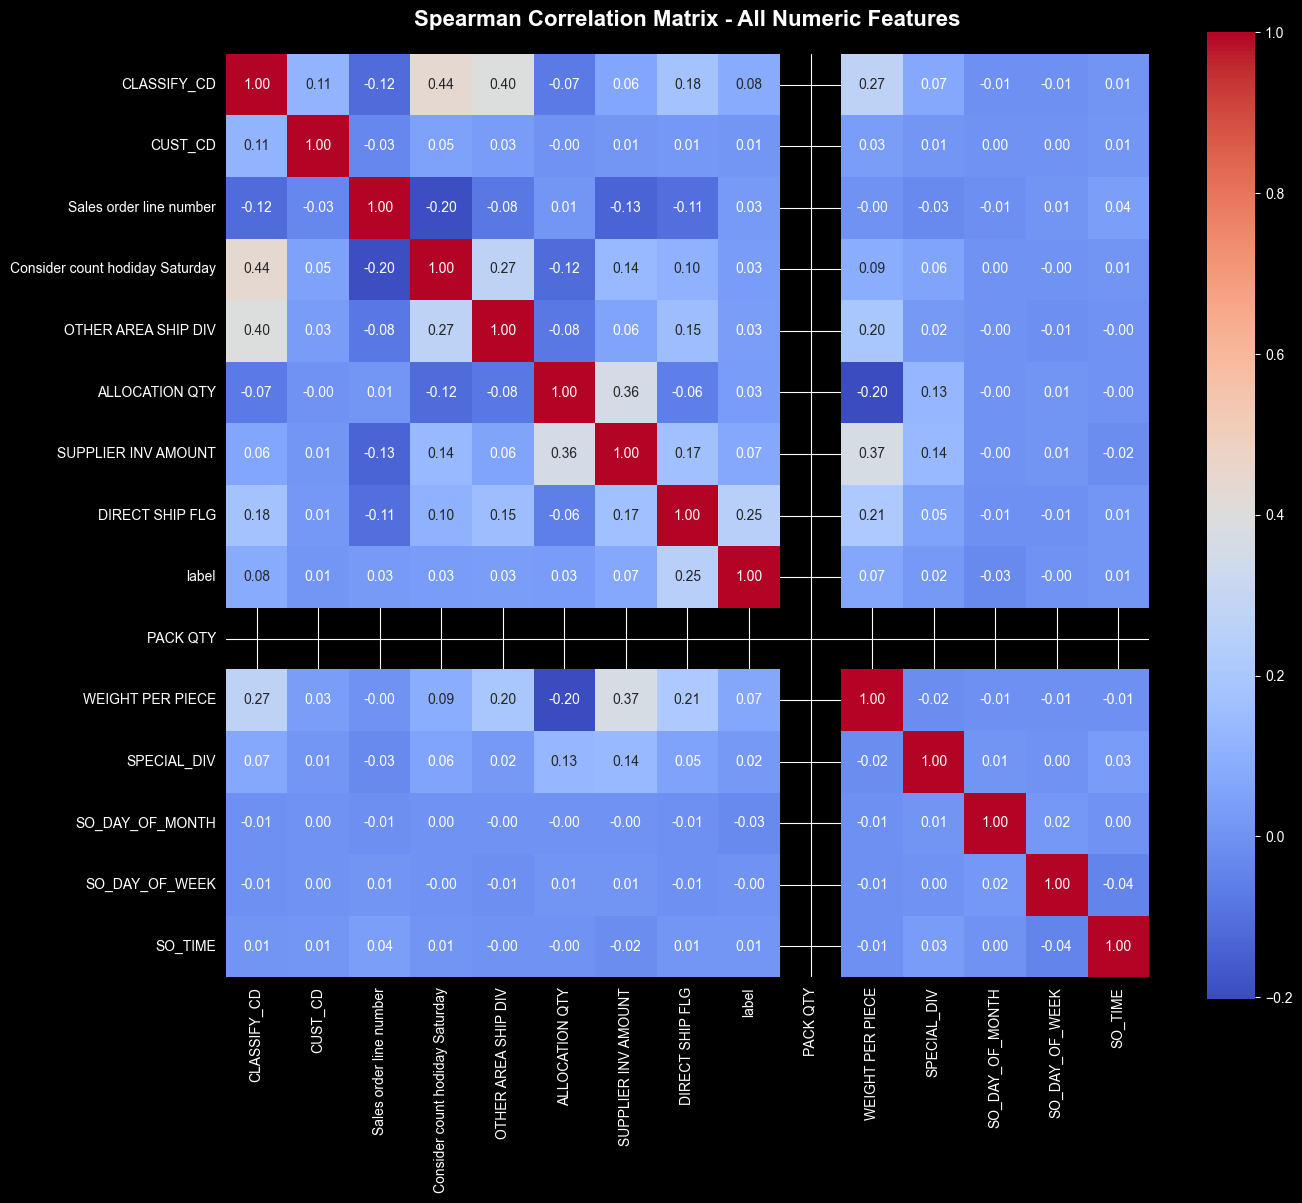


Removing constant columns:
['PACK QTY']

Initial VIF Results:
                            Feature       VIF
12                          SO_TIME  8.052093
11                   SO_DAY_OF_WEEK  4.690903
10                  SO_DAY_OF_MONTH  3.492579
5                    ALLOCATION QTY  3.242755
0                       CLASSIFY_CD  3.129458
6               SUPPLIER INV AMOUNT  2.996480
3   Consider count hodiday Saturday  2.261082
8                  WEIGHT PER PIECE  2.162796
1                           CUST_CD  1.955101
2           Sales order line number  1.801710
4               OTHER AREA SHIP DIV  1.402231
7                   DIRECT SHIP FLG  1.252142
9                       SPECIAL_DIV  1.075227
FINAL VIF RESULTS:
                            Feature       VIF
12                          SO_TIME  8.052093
11                   SO_DAY_OF_WEEK  4.690903
10                  SO_DAY_OF_MONTH  3.492579
5                    ALLOCATION QTY  3.242755
0                       CLASSIFY_CD  3.12945

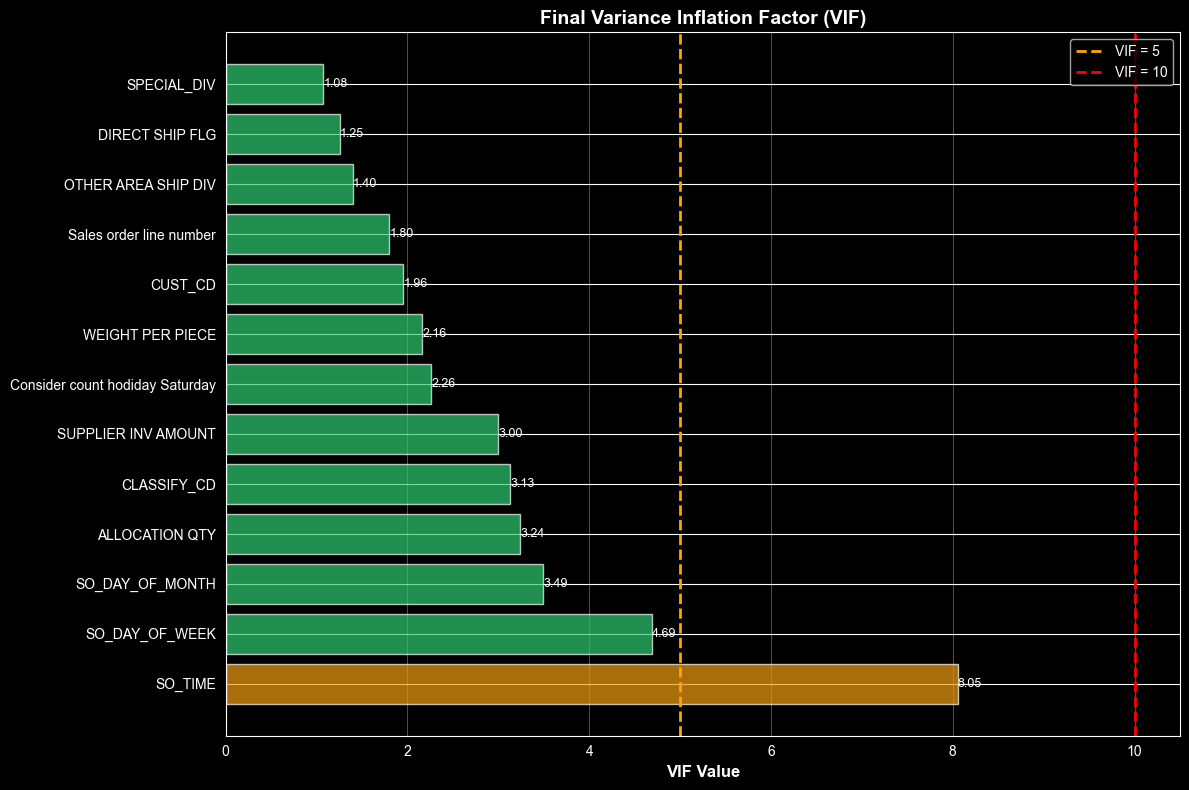

REMOVED FEATURES:
[]

Remaining features:
['Order date', 'CLASSIFY_CD', 'CUST_CD', 'BRAND_CD', 'INNER_CD', 'SUPPLIER_CD', 'Sales order line number', 'Consider count hodiday Saturday', 'OTHER AREA SHIP DIV', 'ALLOCATION QTY', 'SUPPLIER INV AMOUNT', 'PACKING RANK', 'VSD', 'DIRECT SHIP FLG', 'DELI_DIV', 'label', 'Ship Mode', 'PACK QTY', 'WEIGHT PER PIECE', 'SPECIAL_DIV', 'SO_DAY_OF_MONTH', 'SO_DAY_OF_WEEK', 'SO_TIME']


In [62]:
from scipy.stats import spearmanr, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation
numeric_cols = df_7_9.select_dtypes(include=[np.number]).columns.tolist()

spearman_corr = df_7_9[numeric_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
ax.set_title('Spearman Correlation Matrix - All Numeric Features',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# VIF
numeric_cols = df_7_9.select_dtypes(include=[np.number]).columns.tolist()

# Remove target column
if 'label' in numeric_cols:
    numeric_cols.remove('label')

# Prepare data
vif_data = df_7_9[numeric_cols].copy()

# Remove inf values
vif_data = vif_data.replace([np.inf, -np.inf], np.nan)

# Drop missing rows
vif_data = vif_data.dropna()

# Remove constant columns
constant_cols = [
    col for col in vif_data.columns
    if vif_data[col].nunique() <= 1
]

if constant_cols:
    print("\nRemoving constant columns:")
    print(constant_cols)

    vif_data = vif_data.drop(columns=constant_cols)

# Initial VIF
vif_df = calculate_vif(vif_data)

print("\nInitial VIF Results:")
print(vif_df)

# Remove features with extremely high VIF
VIF_THRESHOLD = 10

removed_features = []

while True:

    vif_df = calculate_vif(vif_data)
    max_vif = vif_df['VIF'].max()
    if max_vif <= VIF_THRESHOLD or np.isnan(max_vif):
        break

    feature_to_remove = vif_df.iloc[0]['Feature']
    print(f"\nRemoving '{feature_to_remove}' with VIF = {max_vif:.2f}")
    removed_features.append(feature_to_remove)
    vif_data = vif_data.drop(columns=[feature_to_remove])

# Final VIF Results
final_vif_df = calculate_vif(vif_data)

print("FINAL VIF RESULTS:")
print(final_vif_df)

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

colors = [
    '#e74c3c' if x > 10 else
    '#f39c12' if x > 5 else
    '#2ecc71'
    for x in final_vif_df['VIF']
]

bars = ax.barh(
    range(len(final_vif_df)),
    final_vif_df['VIF'],
    color=colors,
    alpha=0.7
)

ax.set_yticks(range(len(final_vif_df)))
ax.set_yticklabels(final_vif_df['Feature'])

ax.set_xlabel('VIF Value', fontsize=12, fontweight='bold')
ax.set_title(
    'Final Variance Inflation Factor (VIF)',
    fontsize=14,
    fontweight='bold'
)
ax.axvline(
    x=5,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='VIF = 5'
)
ax.axvline(
    x=10,
    color='red',
    linestyle='--',
    linewidth=2,
    label='VIF = 10'
)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add VIF values
for bar, val in zip(bars, final_vif_df['VIF']):

    if np.isfinite(val):

        ax.text(
            val,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            ha='left',
            va='center',
            fontsize=9
        )
plt.tight_layout()
plt.savefig(
    'final_vif_analysis.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Summary
print("REMOVED FEATURES:")
print(removed_features)

# Update df
df_7_9 = df_7_9.drop(columns=removed_features)

print("\nRemaining features:")
print(df_7_9.columns.tolist())

## Feature Engineering ##

### Data Apr - June ###

In [63]:
print(df_4_6['SO_TIME'])


0         120324
1         171618
2         184619
3          93246
4         153401
           ...  
399044    142414
399045    170033
399046    170410
399047     92222
399048    111102
Name: SO_TIME, Length: 399049, dtype: int64


The SO_TIME variable is in HHMMSS format (e.g., 120324 means 12:03:24) ==> Convert to datetime.


In [64]:
# --- Pad leading zeros if needed (ensure 6-digit format) ---
df_4_6['SO_TIME_str'] = df_4_6['SO_TIME'].astype(str).str.zfill(6)

# --- Convert to datetime and extract hour ---
df_4_6['hour'] = pd.to_datetime(df_4_6['SO_TIME_str'], format='%H%M%S').dt.hour

# --- Define time period based on hour ---
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_4_6['time_period'] = df_4_6['hour'].apply(get_time_period)
cat_cols_4_6.append('time_period')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1310666347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=values, palette=mapped_colors)


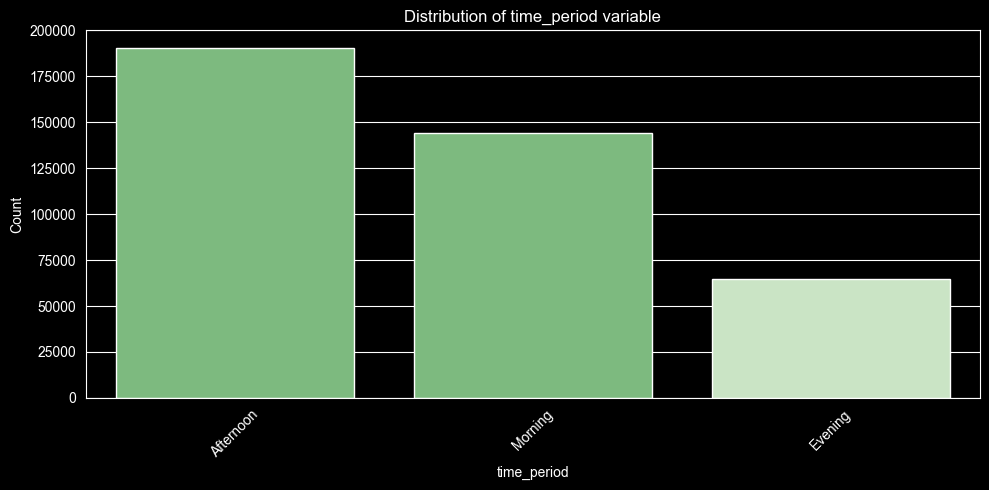

In [65]:
# --- Plot distribution of time_period ---
# Calculate value counts
counts = df_4_6['time_period'].value_counts()
order = counts.index
values = counts.values

# Normalize values to [0, 1] range
norm = (values - values.min()) / (values.max() - values.min() + 1e-9)

# Create color palette
colors = sns.color_palette("Greens", n_colors=len(values))
mapped_colors = [colors[int(v * (len(colors) - 1))] for v in norm]

# Plot with custom colors
plt.figure(figsize=(10, 5))
sns.barplot(x=order, y=values, palette=mapped_colors)
plt.xticks(rotation=45)
plt.title('Distribution of time_period variable')
plt.ylabel('Count')
plt.xlabel('time_period')
plt.tight_layout()
plt.show()

In [66]:
# --- Create binary variable: is weekend or not (Saturday = 5, Sunday = 6) ---
df_4_6['IS_WEEKEND'] = df_4_6['SO_DAY_OF_WEEK'].isin([5, 6]).astype(int)

# --- Group day of month into early / mid / late ---
df_4_6['MONTH_PHASE'] = pd.cut(df_4_6['SO_DAY_OF_MONTH'], bins=[0, 7, 14, 31],
                           labels=['early', 'mid', 'late'])

cat_cols_4_6.append('IS_WEEKEND')
cat_cols_4_6.append('MONTH_PHASE')

In [67]:
df_4_6.dtypes


Order date                         datetime64[us]
CLASSIFY_CD                                 int64
CUST_CD                                     int64
BRAND_CD                                      str
INNER_CD                                      str
SUPPLIER_CD                                   str
Sales order line number                   float64
Consider count hodiday Saturday             int64
OTHER AREA SHIP DIV                           str
ALLOCATION QTY                            float64
PACKING RANK                                  str
PURCHASE AMOUNT                           float64
VSD                                datetime64[us]
DIRECT SHIP FLG                             int64
DELI_DIV                                      str
label                                       int64
Ship Mode                                     str
PACK QTY                                    int64
WEIGHT PER PIECE                            int64
SPECIAL_DIV                                 int64


In [68]:
# --- Extract order month from Order date ---
df_4_6['Order_month'] = df_4_6['Order date'].dt.month

# --- Do the same for VSD (planned shipping date) ---
df_4_6['VSD_month'] = df_4_6['VSD'].dt.month

# --- Create weekend and phase features from VSD date ---
df_4_6['VSD_IS_WEEKEND'] = df_4_6['VSD'].dt.dayofweek.isin([5,6]).astype(int)
df_4_6['VSD_MONTH_PHASE'] = pd.cut(df_4_6['VSD'].dt.day, bins=[0, 7, 14, 31],
                           labels=['early', 'mid', 'late'])

cat_cols_4_6.append('Order_month')
cat_cols_4_6.append('VSD_month')
cat_cols_4_6.append('VSD_IS_WEEKEND')
cat_cols_4_6.append('VSD_MONTH_PHASE')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1205228499.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1205228499.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1205228499.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
C:\Users\ADMIN\AppData\Local

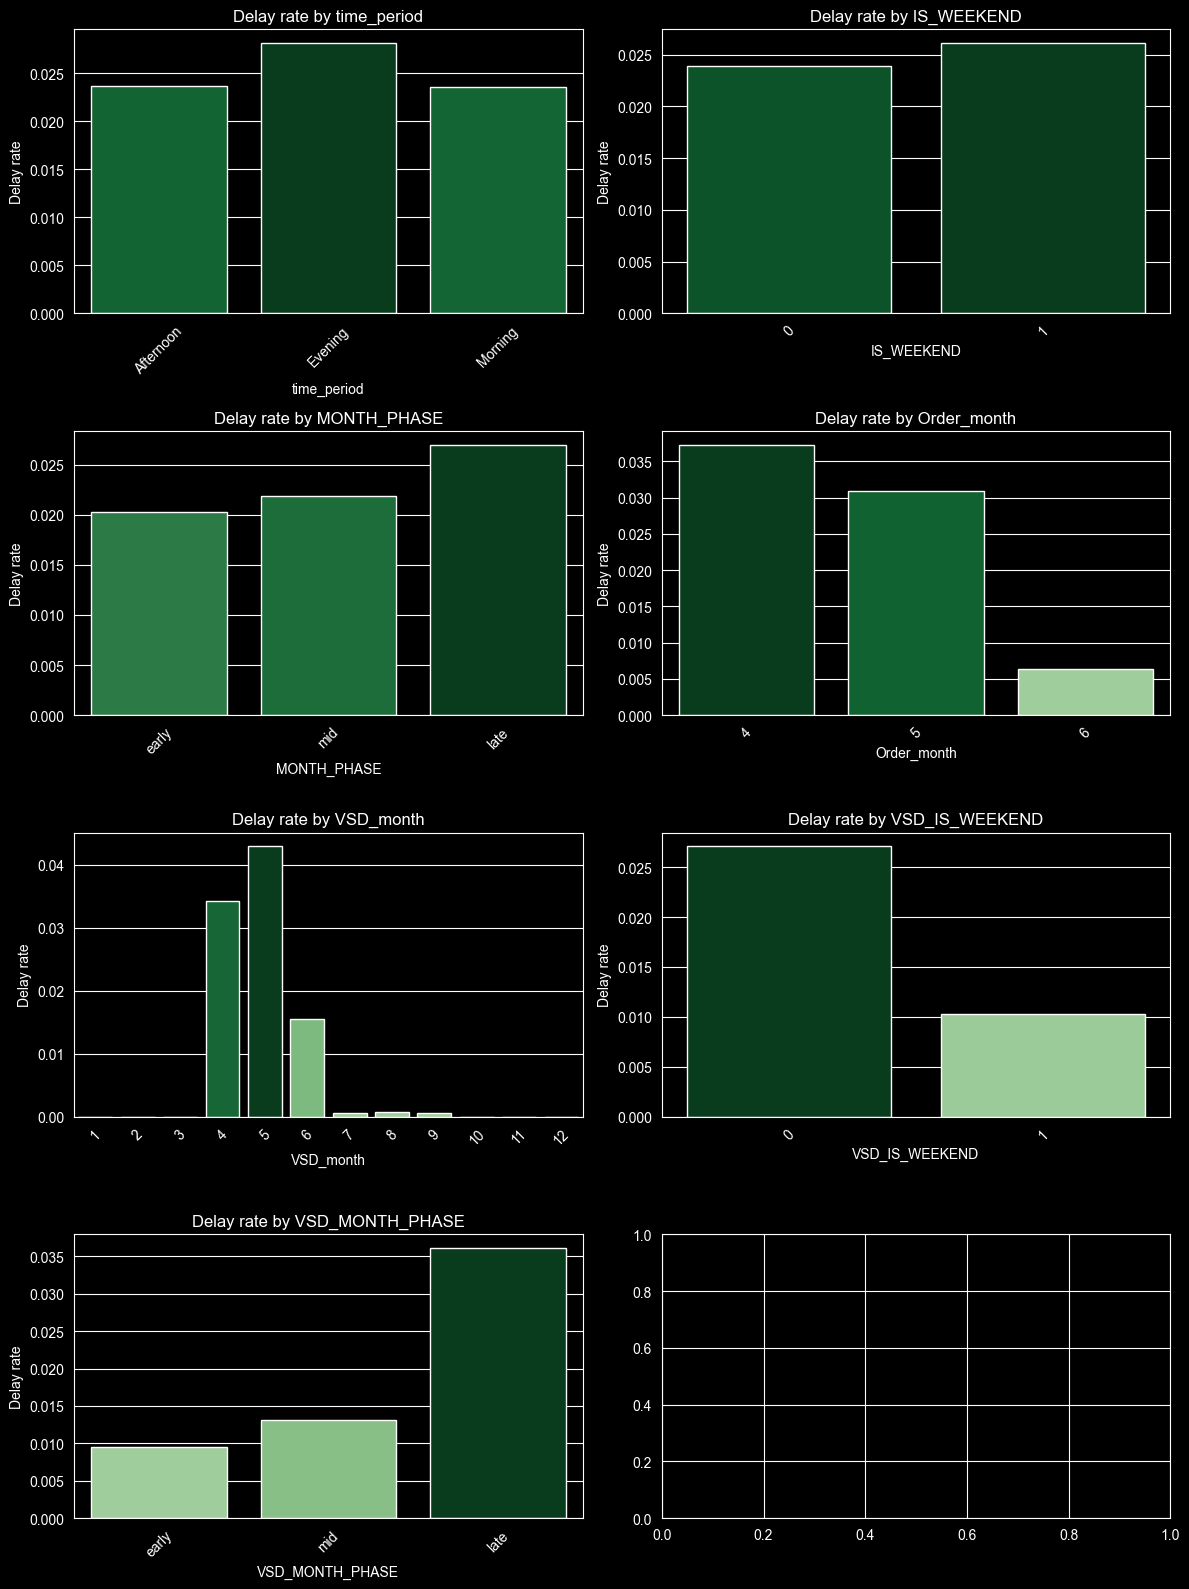

In [69]:
from matplotlib import cm
from matplotlib.colors import ListedColormap
# --- Plot delay rate for each time-related categorical variable ---
cols_to_plot = ['time_period', 'IS_WEEKEND', 'MONTH_PHASE','Order_month',
                'VSD_month', 'VSD_IS_WEEKEND','VSD_MONTH_PHASE']

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Tạo custom colormap (không dùng phần nhạt quá)
custom_greens = ListedColormap(cm.Greens(np.linspace(0.4, 1.0, 256)))

for idx, col in enumerate(cols_to_plot):
    if df_4_6[col].nunique() < 100:
        rate = df_4_6.groupby(col)['label'].mean()

        # Đặt lại ngưỡng ánh xạ, tránh vùng quá nhạt
        norm = plt.Normalize(0.01, rate.max())  # tùy chỉnh min ánh xạ

        # Lấy đúng màu cho từng bar
        colors = [custom_greens(norm(val)) for val in rate.values]

        sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
        axes[idx].set_title(f"Delay rate by {col}")
        axes[idx].set_ylabel("Delay rate")
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("delay_rate_by_time_categorical_sage_fixed.png", dpi=300)
plt.show()

In [71]:
# --- Create numerical feature: expected number of delivery days ---
df_4_6['Expected_delivery_days'] = (df_4_6['VSD'] - df_4_6['Order date']).dt.days
df_4_6['Expected_delivery_days']

# --- Winsorize the feature to handle outliers ---
df_4_6 = winsorize(df_4_6,'Expected_delivery_days')
num_cols_4_6.append('Expected_delivery_days')

[Expected_delivery_days] Winsorized: 49526 outliers clipped.


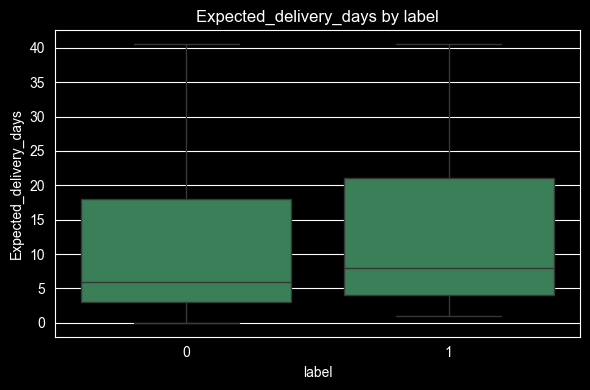

In [72]:
# --- Visualize Expected_delivery_days by label ---
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='Expected_delivery_days', data=df_4_6, color="seagreen")
plt.title("Expected_delivery_days by label")
plt.tight_layout()
plt.show()

### Data Jul - Sep ###

In [74]:
# --- Pad leading zeros if needed (ensure 6-digit format) ---
df_7_9['SO_TIME_str'] = df_7_9['SO_TIME'].astype(str).str.zfill(6)

# --- Convert to datetime and extract hour ---
df_7_9['hour'] = pd.to_datetime(df_7_9['SO_TIME_str'], format='%H%M%S').dt.hour

df_7_9['time_period'] = df_7_9['hour'].apply(get_time_period)
cat_cols_7_9.append('time_period')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1056856635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=values, palette=mapped_colors)


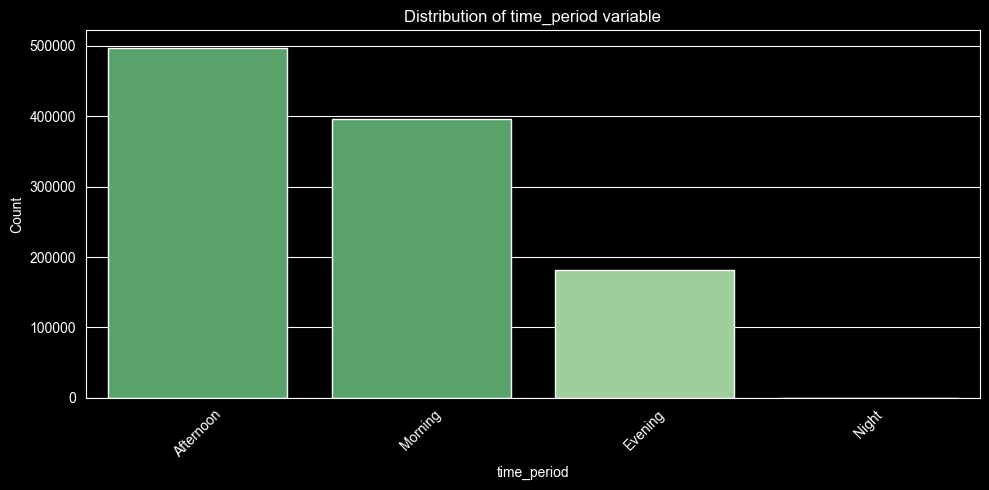

In [75]:
# --- Plot distribution of time_period ---
counts = df_7_9['time_period'].value_counts()
order = counts.index
values = counts.values
norm = (values - values.min()) / (values.max() - values.min() + 1e-9)
colors = sns.color_palette("Greens", n_colors=len(values))
mapped_colors = [colors[int(v * (len(colors) - 1))] for v in norm]

plt.figure(figsize=(10, 5))
sns.barplot(x=order, y=values, palette=mapped_colors)
plt.xticks(rotation=45)
plt.title('Distribution of time_period variable')
plt.ylabel('Count')
plt.xlabel('time_period')
plt.tight_layout()
plt.show()

In [76]:
# --- Create binary variable: is weekend or not (Saturday = 5, Sunday = 6) ---
df_7_9['IS_WEEKEND'] = df_7_9['SO_DAY_OF_WEEK'].isin([5, 6]).astype(int)

# --- Group day of month into early / mid / late ---
df_7_9['MONTH_PHASE'] = pd.cut(df_7_9['SO_DAY_OF_MONTH'], bins=[0, 7, 14, 31],
                           labels=['early', 'mid', 'late'])

cat_cols_7_9.append('IS_WEEKEND')
cat_cols_7_9.append('MONTH_PHASE')

# --- Extract order month from Order date ---
df_7_9['Order_month'] = df_7_9['Order date'].dt.month

# --- Do the same for VSD (planned shipping date) ---
df_7_9['VSD_month'] = df_7_9['VSD'].dt.month

# --- Create weekend and phase features from VSD date ---
df_7_9['VSD_IS_WEEKEND'] = df_7_9['VSD'].dt.dayofweek.isin([5,6]).astype(int)
df_7_9['VSD_MONTH_PHASE'] = pd.cut(df_7_9['VSD'].dt.day, bins=[0, 7, 14, 31],
                           labels=['early', 'mid', 'late'])

cat_cols_7_9.append('Order_month')
cat_cols_7_9.append('VSD_month')
cat_cols_7_9.append('VSD_IS_WEEKEND')
cat_cols_7_9.append('VSD_MONTH_PHASE')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1924614394.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1924614394.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24532\1924614394.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
C:\Users\ADMIN\AppData\Local

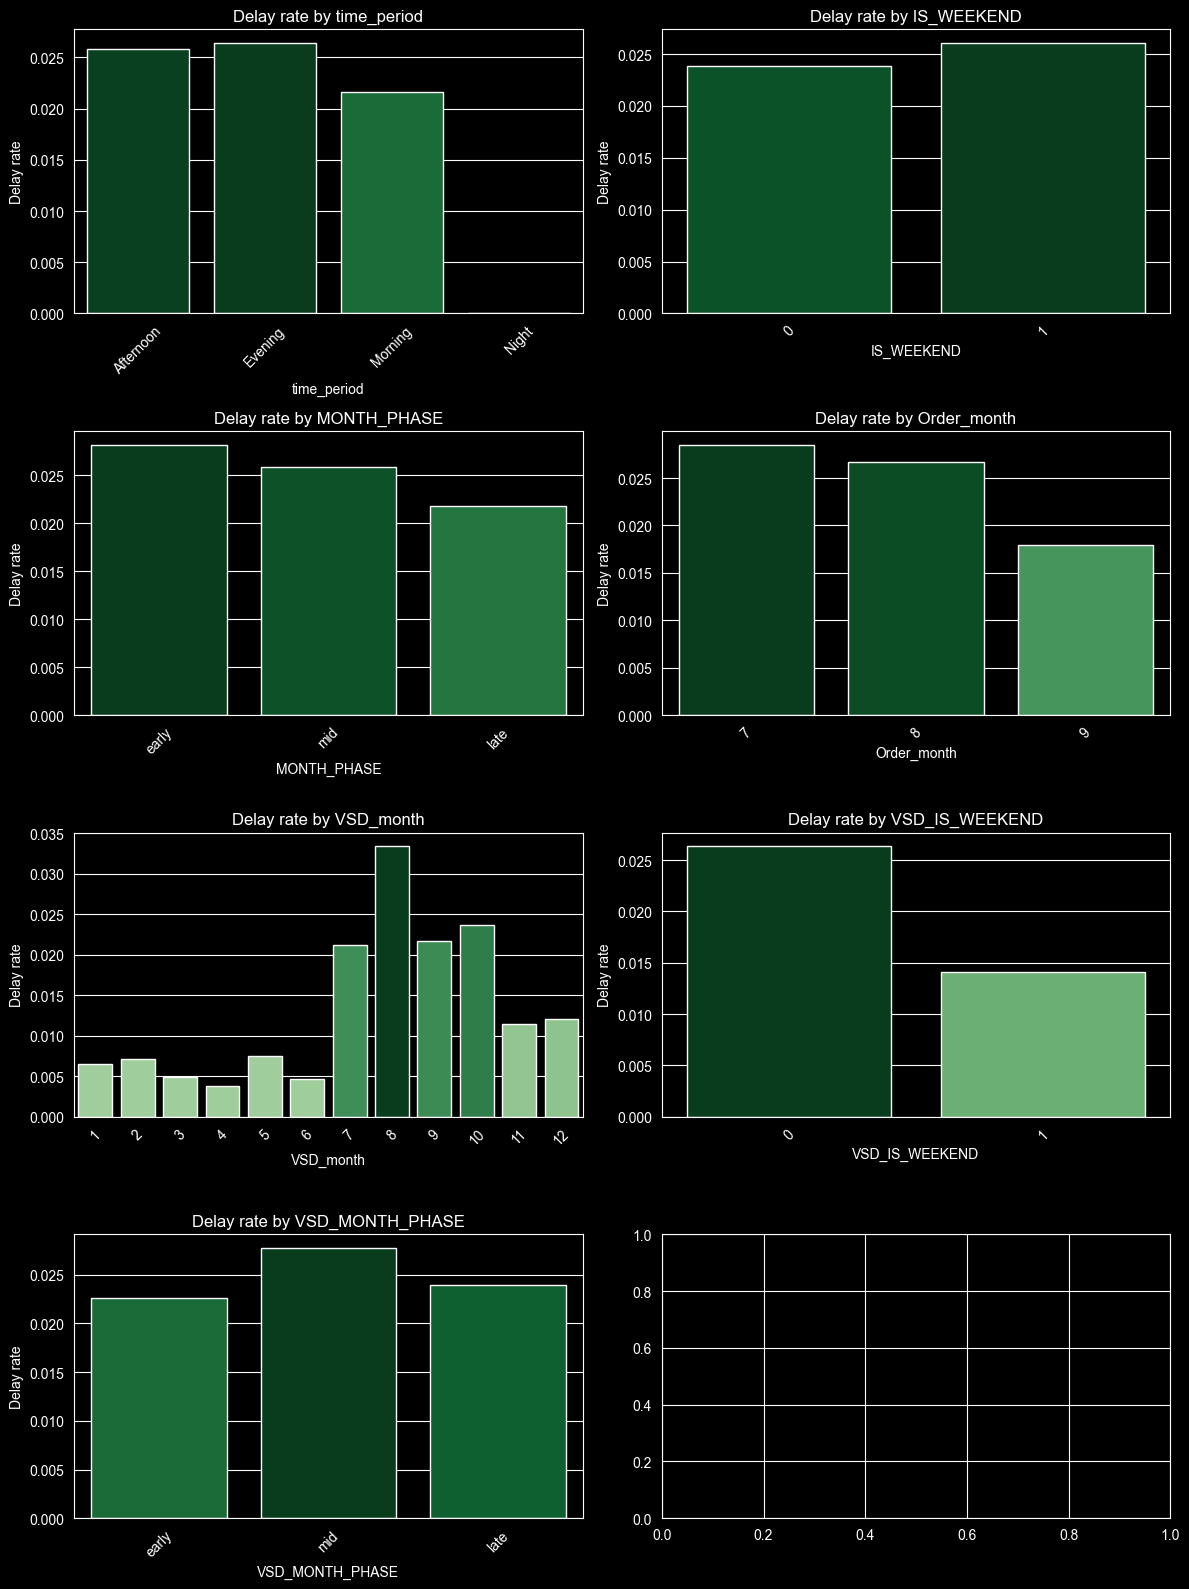

In [77]:
cols_to_plot = ['time_period', 'IS_WEEKEND', 'MONTH_PHASE','Order_month',
                'VSD_month', 'VSD_IS_WEEKEND','VSD_MONTH_PHASE']

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

custom_greens = ListedColormap(cm.Greens(np.linspace(0.4, 1.0, 256)))

for idx, col in enumerate(cols_to_plot):
    if df_7_9[col].nunique() < 100:
        rate = df_7_9.groupby(col)['label'].mean()
        norm = plt.Normalize(0.01, rate.max())
        colors = [custom_greens(norm(val)) for val in rate.values]

        sns.barplot(x=rate.index, y=rate.values, palette=colors, ax=axes[idx])
        axes[idx].set_title(f"Delay rate by {col}")
        axes[idx].set_ylabel("Delay rate")
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("delay_rate_by_time_categorical_7_9.png", dpi=300)
plt.show()

In [79]:
# --- Create numerical feature: expected number of delivery days ---
df_7_9['Expected_delivery_days'] = (df_7_9['VSD'] - df_7_9['Order date']).dt.days

# --- Winsorize the feature to handle outliers ---
df_7_9 = winsorize(df_7_9, 'Expected_delivery_days')
num_cols_7_9.append('Expected_delivery_days')


[Expected_delivery_days] Winsorized: 142630 outliers clipped.


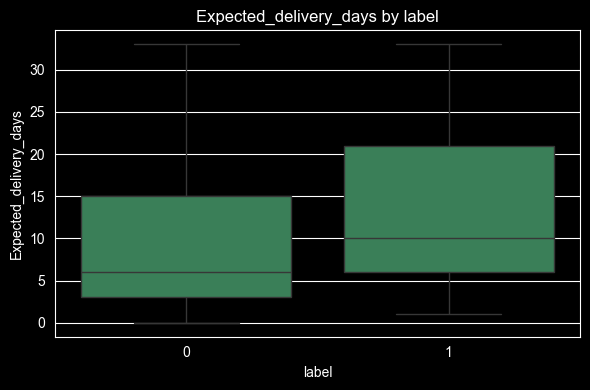

In [80]:
# --- Visualize Expected_delivery_days by label ---
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='Expected_delivery_days', data=df_7_9, color="seagreen")
plt.title("Expected_delivery_days by label")
plt.tight_layout()
plt.show()

## Export Data ##

In [82]:
df_4_6.to_csv("gold_4_6.csv", index=False)
df_7_9.to_csv("gold_7_9.csv", index=False)